**Business Objective**

The objective of this project is to segment countries into meaningful groups based on their economic, social, health, demographic, environmental, and technological development indicators.

Clustering techniques will be applied to identify countries that exhibit similar development characteristics. Multiple clustering algorithms will be developed and evaluated to determine the most appropriate approach for this dataset.

The resulting country segments can help in understanding global development patterns and identifying groups of countries with similar characteristics, which can support comparative analysis and targeted development strategies.

**Problem Statement**

The World Development Measurement dataset contains multiple indicators describing the economic and socio-demographic conditions of countries across the globe.

The objective is to:

- Analyze and preprocess the available development indicators.
- Construct a representative development profile for each country.
- Apply different clustering techniques to group countries with similar characteristics.
- Compare the performance of the clustering models using appropriate evaluation metrics.
- Interpret the characteristics of the resulting clusters.
- Select the most suitable clustering approach for the application.
- Deploy the final clustering solution using Streamlit.

**Clustering Approach**

The dataset contains multiple observations for each country. Since the business objective is to segment countries, rather than individual observations, the analysis will first aggregate the available observations for each country to create a single country-level development profile.

The resulting dataset will contain approximately 208 countries, with each country represented by its development indicators.

The following clustering techniques will be evaluated:

- K-Means Clustering
- Hierarchical (Agglomerative) Clustering
- DBSCAN

The models will be compared using clustering evaluation metrics, primarily the Silhouette Score, along with cluster size, stability, interpretability, and suitability for the business objective.

**Importing Libraries**

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Clustering evaluation
from sklearn.metrics import silhouette_score

# Hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Dimensionality reduction
from sklearn.decomposition import PCA

# Model persistence
import joblib

# Display settings
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

**Loading Dataset**

In [3]:
df = pd.read_excel("World_development_mesurement (2).xlsx")

**Dataset Preview**

In [4]:
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,NaN,0.034,0.0,0.100,71.0,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,NaN,0.128,0.0,1.032,47.0,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,NaN,0.090,0.0,NaN,57.0,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,NaN,0.054,0.0,0.155,52.0,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,NaN,0.096,0.0,NaN,52.0,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


# Initial Dataset Inspection

**Dataset Dimensions:**

In [5]:
# Checking the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2704
Number of columns: 25


**Dataset Information:**

In [6]:
# Displaying dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

**Descriptive Statistics:**

In [7]:
# Generating descriptive statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Birth Rate,2585.0,2.271489e-02,1.133843e-02,0.007,0.01300,2.000000e-02,3.100000e-02,5.300000e-02
CO2 Emissions,2125.0,1.423071e+05,6.159288e+05,7.000,1360.00000,8.529000e+03,5.910800e+04,8.286892e+06
Days to Start Business,1718.0,3.999942e+01,5.731859e+01,1.000,13.00000,2.600000e+01,4.500000e+01,6.940000e+02
Ease of Business,185.0,9.487568e+01,5.479191e+01,1.000,48.00000,9.400000e+01,1.420000e+02,1.890000e+02
Energy Usage,1785.0,7.723684e+04,2.599239e+05,8.000,3737.00000,1.433800e+04,4.185200e+04,2.727728e+06
Health Exp % GDP,2395.0,6.416952e-02,2.632460e-02,0.008,0.04600,6.100000e-02,7.900000e-02,2.250000e-01
Hours to do Tax,1416.0,3.020685e+02,2.732997e+02,12.000,156.00000,2.390000e+02,3.447500e+02,2.600000e+03
Infant Mortality Rate,2444.0,3.281301e-02,2.996760e-02,0.002,0.00900,2.000000e-02,5.300000e-02,1.410000e-01
Internet Usage,2531.0,2.397471e-01,2.601318e-01,0.000,0.00000,1.000000e-01,4.000000e-01,1.000000e+00
Lending Interest,1880.0,1.481027e-01,1.718291e-01,0.005,0.08000,1.200000e-01,1.730000e-01,4.965000e+00


**Missing Values:**

In [8]:
# Checking the number and percentage of missing values
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by='Missing Percentage',
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
Ease of Business,2519,93.158284
Hours to do Tax,1288,47.633136
Business Tax Rate,1281,47.374260
Days to Start Business,986,36.464497
Energy Usage,919,33.986686
Lending Interest,824,30.473373
CO2 Emissions,579,21.412722
Tourism Outbound,471,17.418639
Tourism Inbound,368,13.609467
Health Exp % GDP,309,11.427515


**Duplicate Records:**

In [9]:
# Checking for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Country-Level Observation Check:**

In [10]:
# Checking the number of unique countries
print("Number of unique countries:", df['Country'].nunique())

# Checking how many observations exist for each country
country_counts = df['Country'].value_counts()

print("\nObservations per country:")
print(country_counts.value_counts().sort_index())

Number of unique countries: 208

Observations per country:
count
13    208
Name: count, dtype: int64


In [11]:
# Displaying countries with their number of observations
country_counts.sort_index().to_frame(name='Number of Observations').head(20)

,Number of Observations
Country,
Afghanistan,13
Albania,13
Algeria,13
American Samoa,13
Andorra,13
Angola,13
Antigua and Barbuda,13
Argentina,13
Armenia,13


**Checking Whether Country Records Are Consistent:**

In [12]:
# Checking the range of observation counts across countries
print("Minimum observations for a country:", country_counts.min())
print("Maximum observations for a country:", country_counts.max())

# Displaying countries that do not have exactly 13 observations
countries_not_13 = country_counts[country_counts != 13]

print("\nCountries not having exactly 13 observations:")
print(countries_not_13)

Minimum observations for a country: 13
Maximum observations for a country: 13

Countries not having exactly 13 observations:
Series([], Name: count, dtype: int64)


**Understanding Repeated Country Observations**

Each country occurs exactly 13 times in the dataset. Since the dataset does not contain an explicit year variable, the repeated observations will first be examined to understand whether the values vary substantially across records.

This assessment will help determine an appropriate method for constructing a single representative development profile for each country.

In [13]:
# Inspecting all 13 observations for selected countries
countries_to_check = ['Algeria', 'India', 'United States']

for country in countries_to_check:
    print(f"\n{'='*70}")
    print(f"{country}")
    print(f"{'='*70}")
    
    display(
        df[df['Country'] == country].T
    )


Algeria


,0,208,416,624,832,1040,1248,1456,1664,1872,2080,2288,2496
Birth Rate,0.02,0.019,0.019,0.02,0.02,0.021,0.022,0.023,0.024,0.024,0.025,0.025,0.025
Business Tax Rate,NaN,NaN,NaN,NaN,NaN,76.9%,76.9%,74.2%,73.8%,72.0%,72.0%,72.0%,71.9%
CO2 Emissions,87931.0,84293.0,90854.0,92533.0,89493.0,107128.0,103963.0,112339.0,114619.0,124586.0,123475.0,NaN,NaN
Country,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria
Days to Start Business,NaN,NaN,NaN,25.0,25.0,25.0,25.0,25.0,25.0,25.0,25.0,25.0,25.0
Ease of Business,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,151.0
Energy Usage,26998.0,27072.0,28773.0,30698.0,30974.0,32335.0,34658.0,36793.0,37425.0,40823.0,40105.0,41852.0,NaN
GDP,"$54,790,058,957","$54,744,716,706","$56,760,288,962","$67,863,832,648","$85,324,997,370","$103,198,650,298","$117,026,655,314","$134,977,867,932","$171,000,162,581","$137,211,795,394","$161,207,304,960","$199,070,864,638","$204,331,017,992"
Health Exp % GDP,0.035,0.038,0.037,0.036,0.035,0.031,0.031,0.035,0.038,0.046,0.042,0.044,0.052
Health Exp/Capita,$60,$65,$65,$74,$90,$95,$106,$135,$183,$174,$181,$233,$279



India


,63,271,479,687,895,1103,1311,1519,1727,1935,2143,2351,2559
Birth Rate,0.026,0.025,0.025,0.024,0.024,0.023,0.023,0.022,0.022,0.022,0.021,0.021,0.021
Business Tax Rate,NaN,NaN,NaN,NaN,NaN,66.6%,74.0%,72.7%,70.3%,66.0%,64.9%,62.9%,62.8%
CO2 Emissions,1186663.0,1203843.0,1226791.0,1281914.0,1348525.0,1411128.0,1504365.0,1611404.0,1811289.0,1982263.0,2008823.0,NaN,NaN
Country,India,India,India,India,India,India,India,India,India,India,India,India,India
Days to Start Business,NaN,NaN,NaN,89.0,89.0,71.0,35.0,33.0,30.0,30.0,29.0,29.0,27.0
Ease of Business,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,131.0
Energy Usage,457198.0,464501.0,477540.0,489507.0,519165.0,539388.0,567182.0,604659.0,632956.0,698360.0,723743.0,749447.0,NaN
GDP,"$476,609,148,166","$493,954,333,981","$523,968,561,884","$618,356,467,438","$721,585,608,184","$834,215,013,605","$949,116,769,619","$1,238,700,195,644","$1,224,097,069,460","$1,365,372,433,342","$1,708,458,876,830","$1,880,100,141,185","$1,858,744,737,180"
Health Exp % GDP,0.043,0.045,0.044,0.043,0.045,0.042,0.04,0.039,0.039,0.039,0.037,0.039,0.04
Health Exp/Capita,$20,$21,$21,$24,$29,$32,$33,$40,$43,$44,$52,$62,$61



United States


,204,412,620,828,1036,1244,1452,1660,1868,2076,2284,2492,2700
Birth Rate,0.014,0.014,0.014,0.014,0.014,0.014,0.014,0.014,0.014,0.014,0.013,0.013,0.013
Business Tax Rate,NaN,NaN,NaN,NaN,NaN,45.8%,47.4%,46.1%,46.4%,46.1%,46.5%,46.5%,46.4%
CO2 Emissions,5713560.0,5601405.0,5650950.0,5681664.0,5790765.0,5826394.0,5737616.0,5828697.0,5656839.0,5311840.0,5433057.0,NaN,NaN
Country,United States,United States,United States,United States,United States,United States,United States,United States,United States,United States,United States,United States,United States
Days to Start Business,NaN,NaN,NaN,6.0,6.0,6.0,6.0,6.0,5.0,5.0,5.0,5.0,5.0
Ease of Business,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
Energy Usage,2273332.0,2230817.0,2255957.0,2261151.0,2307819.0,2318861.0,2296686.0,2337014.0,2277034.0,2164458.0,2215504.0,2191193.0,2132446.0
GDP,"$10,289,700,000,000","$10,625,300,000,000","$10,980,200,000,000","$11,512,200,000,000","$12,277,000,000,000","$13,095,400,000,000","$13,857,900,000,000","$14,480,300,000,000","$14,720,300,000,000","$14,417,900,000,000","$14,958,300,000,000","$15,533,800,000,000","$16,244,600,000,000"
Health Exp % GDP,0.136,0.142,0.151,0.156,0.157,0.158,0.159,0.161,0.165,0.177,0.177,0.177,0.179
Health Exp/Capita,"$4,790","$5,138","$5,578","$5,993","$6,355","$6,732","$7,110","$7,486","$7,769","$8,009","$8,254","$8,467","$8,895"


In [14]:
# Measuring how much each numerical variable varies within countries
numeric_cols = df.select_dtypes(include=['number']).columns

country_variation = df.groupby('Country')[numeric_cols].agg(['min', 'max', 'mean', 'std'])

country_variation.head()

Birth Rate                            CO2 Emissions            \
                      min    max      mean       std           min       max   
Country                                                                        
Afghanistan         0.035  0.050  0.043154  0.004879         359.0    8236.0   
Albania             0.013  0.019  0.014692  0.002136        3022.0    4294.0   
Algeria             0.019  0.025  0.022077  0.002362       84293.0  124586.0   
American Samoa      0.019  0.022  0.020500  0.002121           NaN       NaN   
Andorra             0.010  0.012  0.010583  0.000669         517.0     576.0   

                                            Days to Start Business        \
                         mean           std                    min   max   
Country                                                                    
Afghanistan       2375.727273   2693.498583                    7.0   9.0   
Albania           3902.090909    427.523673                    5.0  41.0   
Algeria         102837.636364  14634.295127                   25.0  25.0   
American Samoa            NaN           NaN                    NaN   NaN   
Andorra            537.636364     18.858806                    NaN   NaN   

                                     Ease of Business                    \
                     mean        std              min    max   mean std   
Country                                                                   
Afghanistan      8.111111   1.054093            170.0  170.0  170.0 NaN   
Albania         23.000000  17.587875             82.0   82.0   82.0 NaN   
Algeria         25.000000   0.000000            151.0  151.0  151.0 NaN   
American Samoa        NaN        NaN              NaN    NaN    NaN NaN   
Andorra               NaN        NaN              NaN    NaN    NaN NaN   

               Energy Usage                                      \
                        min      max          mean          std   
Country                                                           
Afghanistan             NaN      NaN           NaN          NaN   
Albania              1763.0   2173.0   2024.583333   135.974234   
Algeria             26998.0  41852.0  34042.166667  5330.872193   
American Samoa          NaN      NaN           NaN          NaN   
Andorra                 NaN      NaN           NaN          NaN   

               Health Exp % GDP                            Hours to do Tax  \
                            min    max      mean       std             min   
Country                                                                      
Afghanistan               0.084  0.100  0.091909  0.005907           275.0   
Albania                   0.055  0.065  0.061462  0.002787           357.0   
Algeria                   0.031  0.052  0.038462  0.006050           451.0   
American Samoa              NaN    NaN       NaN       NaN             NaN   
Andorra                   0.056  0.083  0.063231  0.007823             NaN   

                                       Infant Mortality Rate                   \
                  max   mean       std                   min    max      mean   
Country                                                                         
Afghanistan     275.0  275.0  0.000000                 0.072  0.095  0.082769   
Albania         371.0  364.5  4.535574                 0.014  0.023  0.017769   
Algeria         451.0  451.0  0.000000                 0.022  0.034  0.027769   
American Samoa    NaN    NaN       NaN                   NaN    NaN       NaN   
Andorra           NaN    NaN       NaN                 0.002  0.004  0.003000   

                         Internet Usage                           \
                     std            min  max      mean       std   
Country                                                            
Afghanistan     0.007474            0.0  0.1  0.016667  0.038925   
Albania         0.003032            0.0  0.5  0.192308  0.210006   
Algeria      

In [15]:
# Average within-country standard deviation for each variable
avg_within_country_std = (
    df.groupby('Country')[numeric_cols]
      .std()
      .mean()
      .sort_values(ascending=False)
)

avg_within_country_std

Population Total          1.517820e+06
CO2 Emissions             1.789779e+04
Energy Usage              7.503102e+03
Hours to do Tax           3.017583e+01
Days to Start Business    1.150222e+01
Life Expectancy Male      1.330982e+00
Life Expectancy Female    1.297653e+00
Mobile Phone Usage        3.074154e-01
Internet Usage            1.111119e-01
Lending Interest          4.264312e-02
Population 0-14           1.420592e-02
Population Urban          1.300424e-02
Population 15-64          1.199969e-02
Health Exp % GDP          7.623371e-03
Infant Mortality Rate     4.497428e-03
Population 65+            4.137113e-03
Birth Rate                1.192331e-03
Number of Records         0.000000e+00
Ease of Business                   NaN
dtype: float64

# Data Preprocessing & Country-Level Aggregation

## Data Type Conversion

Several development indicators are stored as text because they contain currency symbols ($) or percentage symbols (%). These values must be converted into numerical form before performing aggregation and clustering.

The following columns require conversion:

- Business Tax Rate
- GDP
- Health Exp/Capita
- Tourism Inbound
- Tourism Outbound

In [16]:
# Columns containing currency or percentage formatted values
currency_cols = [
    'GDP',
    'Health Exp/Capita',
    'Tourism Inbound',
    'Tourism Outbound'
]

percentage_cols = [
    'Business Tax Rate'
]

# Convert currency columns to numeric
for col in currency_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .replace('nan', np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Converting percentage column to numeric
for col in percentage_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .replace('nan', np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [17]:
# Verifying data types after conversion
df[currency_cols + percentage_cols].dtypes

GDP                  float64
Health Exp/Capita    float64
Tourism Inbound      float64
Tourism Outbound     float64
Business Tax Rate    float64
dtype: object

In [18]:
# Displaying converted values
df[currency_cols + percentage_cols].head()

,GDP,Health Exp/Capita,Tourism Inbound,Tourism Outbound,Business Tax Rate
0,5.479006e+10,60.0,102000000.0,193000000.0,NaN
1,9.129595e+09,22.0,34000000.0,146000000.0,NaN
2,2.359122e+09,15.0,77000000.0,50000000.0,NaN
3,5.788312e+09,152.0,227000000.0,209000000.0,NaN
4,2.610959e+09,12.0,23000000.0,30000000.0,NaN


## Removing Non-Informative Variables

**Number of Records** column contains the value 1 for every observation and therefore provides no information for distinguishing countries. It will not contribute to clustering and is removed from the analysis.

In [19]:
df = df.drop(columns=['Number of Records'])

In [20]:
df.shape

(2704, 24)

## Creating the Country-Level Dataset

**Creating Country-Level Development Profiles**

Each country has exactly 13 observations. Since the objective is to cluster countries rather than individual observations, the observations are aggregated at the country level.

For each numerical development indicator, the mean of the available observations is calculated. This produces one representative development profile for each country.

In [21]:
# Identifying numerical features
numeric_features = df.select_dtypes(include=['number']).columns.tolist()

# Creating one development profile per country
country_df = (
    df.groupby('Country')[numeric_features]
      .mean()
      .reset_index()
)

In [22]:
# Displaying the resulting country-level dataset
country_df.head()

,Country,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,Afghanistan,0.043154,36.3000,2375.727273,8.111111,170.0,NaN,9.718945e+09,0.091909,30.636364,275.0,0.082769,0.016667,0.159714,58.769231,56.384615,0.254545,0.490308,0.488769,0.020769,2.539926e+07,0.232923,1.060000e+08,8.240000e+07
1,Albania,0.014692,42.5500,3902.090909,23.000000,82.0,2024.583333,8.895522e+09,0.061462,168.846154,364.5,0.017769,0.192308,0.142385,79.230769,73.000000,0.561538,0.258385,0.653692,0.087923,2.956845e+06,0.478538,1.165231e+09,1.007077e+09
2,Algeria,0.022077,73.7125,102837.636364,25.000000,151.0,34042.166667,1.190391e+11,0.038462,133.846154,451.0,0.027769,0.069231,0.083231,71.615385,68.384615,0.492308,0.292692,0.663077,0.044231,3.476067e+07,0.645154,2.752308e+08,4.513077e+08
3,American Samoa,0.020500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,5.752538e+04,0.880000,NaN,NaN
4,Andorra,0.010583,NaN,537.636364,NaN,NaN,NaN,2.268380e+09,0.063231,2394.461538,NaN,0.003000,0.516667,NaN,NaN,NaN,0.700000,NaN,NaN,NaN,7.668408e+04,0.897462,NaN,NaN


In [23]:
print("Number of countries:", country_df['Country'].nunique())
print("Number of features:", country_df.shape[1] - 1)
print("Shape of country-level dataset:", country_df.shape)

Number of countries: 208
Number of features: 23
Shape of country-level dataset: (208, 24)


## Check Missing Values After Aggregation

In [24]:
# Checking missing values in the country-level dataset
country_missing_summary = pd.DataFrame({
    'Missing Values': country_df.isnull().sum(),
    'Missing Percentage': (country_df.isnull().sum() / len(country_df)) * 100
})

country_missing_summary = country_missing_summary.sort_values(
    by='Missing Percentage',
    ascending=False
)

country_missing_summary

,Missing Values,Missing Percentage
Lending Interest,45,21.634615
Energy Usage,41,19.711538
Business Tax Rate,23,11.057692
Days to Start Business,23,11.057692
Ease of Business,23,11.057692
Health Exp % GDP,23,11.057692
Health Exp/Capita,23,11.057692
Hours to do Tax,23,11.057692
Tourism Outbound,22,10.576923
Infant Mortality Rate,20,9.615385


## Handling Missing Values

**Missing Value Analysis at Country Level**

After aggregating the observations for each country, the amount of missing data is substantially reduced. Missing values are handled at the country-profile level rather than at the individual observation level.

Since the clustering algorithms require complete numerical feature vectors, the remaining missing values will be imputed using the median of the corresponding feature. Median imputation is selected because several development indicators are highly skewed and contain substantial differences between countries.

### Visualizing Missingness

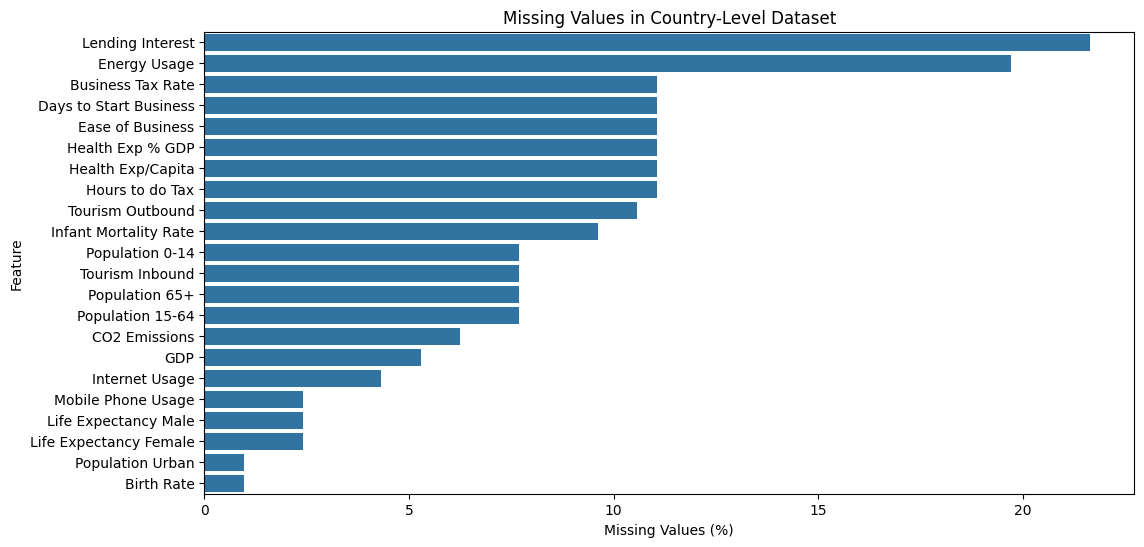

In [25]:
# Visualizing missing values at country level

plt.figure(figsize=(12, 6))

missing_pct = (
    country_df.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct = missing_pct[missing_pct > 0]

sns.barplot(
    x=missing_pct.values,
    y=missing_pct.index
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Values in Country-Level Dataset")
plt.show()

### Median Imputation

In [26]:
# Separating country identifier from numerical features
country_names = country_df['Country']

feature_cols = [
    col for col in country_df.columns
    if col != 'Country'
]

In [27]:
# Imputing missing numerical values using the median
country_df[feature_cols] = country_df[feature_cols].fillna(
    country_df[feature_cols].median()
)

In [28]:
# Verifying that no missing values remain
country_df[feature_cols].isnull().sum().sort_values(ascending=False)

Birth Rate                0
Lending Interest          0
Tourism Inbound           0
Population Urban          0
Population Total          0
Population 65+            0
Population 15-64          0
Population 0-14           0
Mobile Phone Usage        0
Life Expectancy Male      0
Life Expectancy Female    0
Internet Usage            0
Business Tax Rate         0
Infant Mortality Rate     0
Hours to do Tax           0
Health Exp/Capita         0
Health Exp % GDP          0
GDP                       0
Energy Usage              0
Ease of Business          0
Days to Start Business    0
CO2 Emissions             0
Tourism Outbound          0
dtype: int64

In [29]:
print("Total missing values after imputation:", country_df[feature_cols].isnull().sum().sum())

Total missing values after imputation: 0


## Verifying the Clean Dataset

In [30]:
# Final country-level dataset information
print("Dataset shape:", country_df.shape)
print("Number of countries:", country_df['Country'].nunique())
print("Number of features:", len(feature_cols))
print("Total missing values:", country_df[feature_cols].isnull().sum().sum())

Dataset shape: (208, 24)
Number of countries: 208
Number of features: 23
Total missing values: 0


# Exploratory Data Analysis (EDA)

**Exploratory data analysis** is performed on the country-level development dataset to understand the distribution, scale, variability, and relationships among the development indicators before applying clustering algorithms.

## Descriptive Statistics

In [31]:
# Descriptive statistics of country-level development indicators
country_df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Birth Rate,208.0,2.247695e-02,1.116468e-02,8.384615e-03,1.294231e-02,1.957692e-02,2.903846e-02,5.115385e-02
Business Tax Rate,208.0,4.759150e+01,3.618581e+01,8.400000e+00,3.372500e+01,4.106250e+01,4.925625e+01,3.074000e+02
CO2 Emissions,208.0,1.327964e+05,5.841549e+05,1.725000e+01,1.607023e+03,7.856455e+03,5.379448e+04,5.673742e+06
Days to Start Business,208.0,3.922464e+01,5.446794e+01,3.000000e+00,1.948611e+01,2.770000e+01,4.115000e+01,6.940000e+02
Ease of Business,208.0,9.477885e+01,5.165904e+01,1.000000e+00,5.375000e+01,9.400000e+01,1.362500e+02,1.890000e+02
Energy Usage,208.0,5.487631e+04,2.148227e+05,9.250000e+00,2.939521e+03,8.974167e+03,2.553769e+04,2.250944e+06
GDP,208.0,2.445983e+11,1.062132e+12,1.145310e+08,4.031795e+09,1.706592e+10,1.036772e+11,1.330715e+13
Health Exp % GDP,208.0,6.368810e-02,2.354928e-02,2.061538e-02,4.917308e-02,6.076923e-02,7.625000e-02,1.803846e-01
Health Exp/Capita,208.0,7.341906e+02,1.333765e+03,8.538462e+00,6.501923e+01,2.193846e+02,5.610577e+02,6.967385e+03
Hours to do Tax,208.0,2.929016e+02,2.490086e+02,1.200000e+01,1.680312e+02,2.410000e+02,3.359062e+02,2.600000e+03


## Distribution of Development Indicators

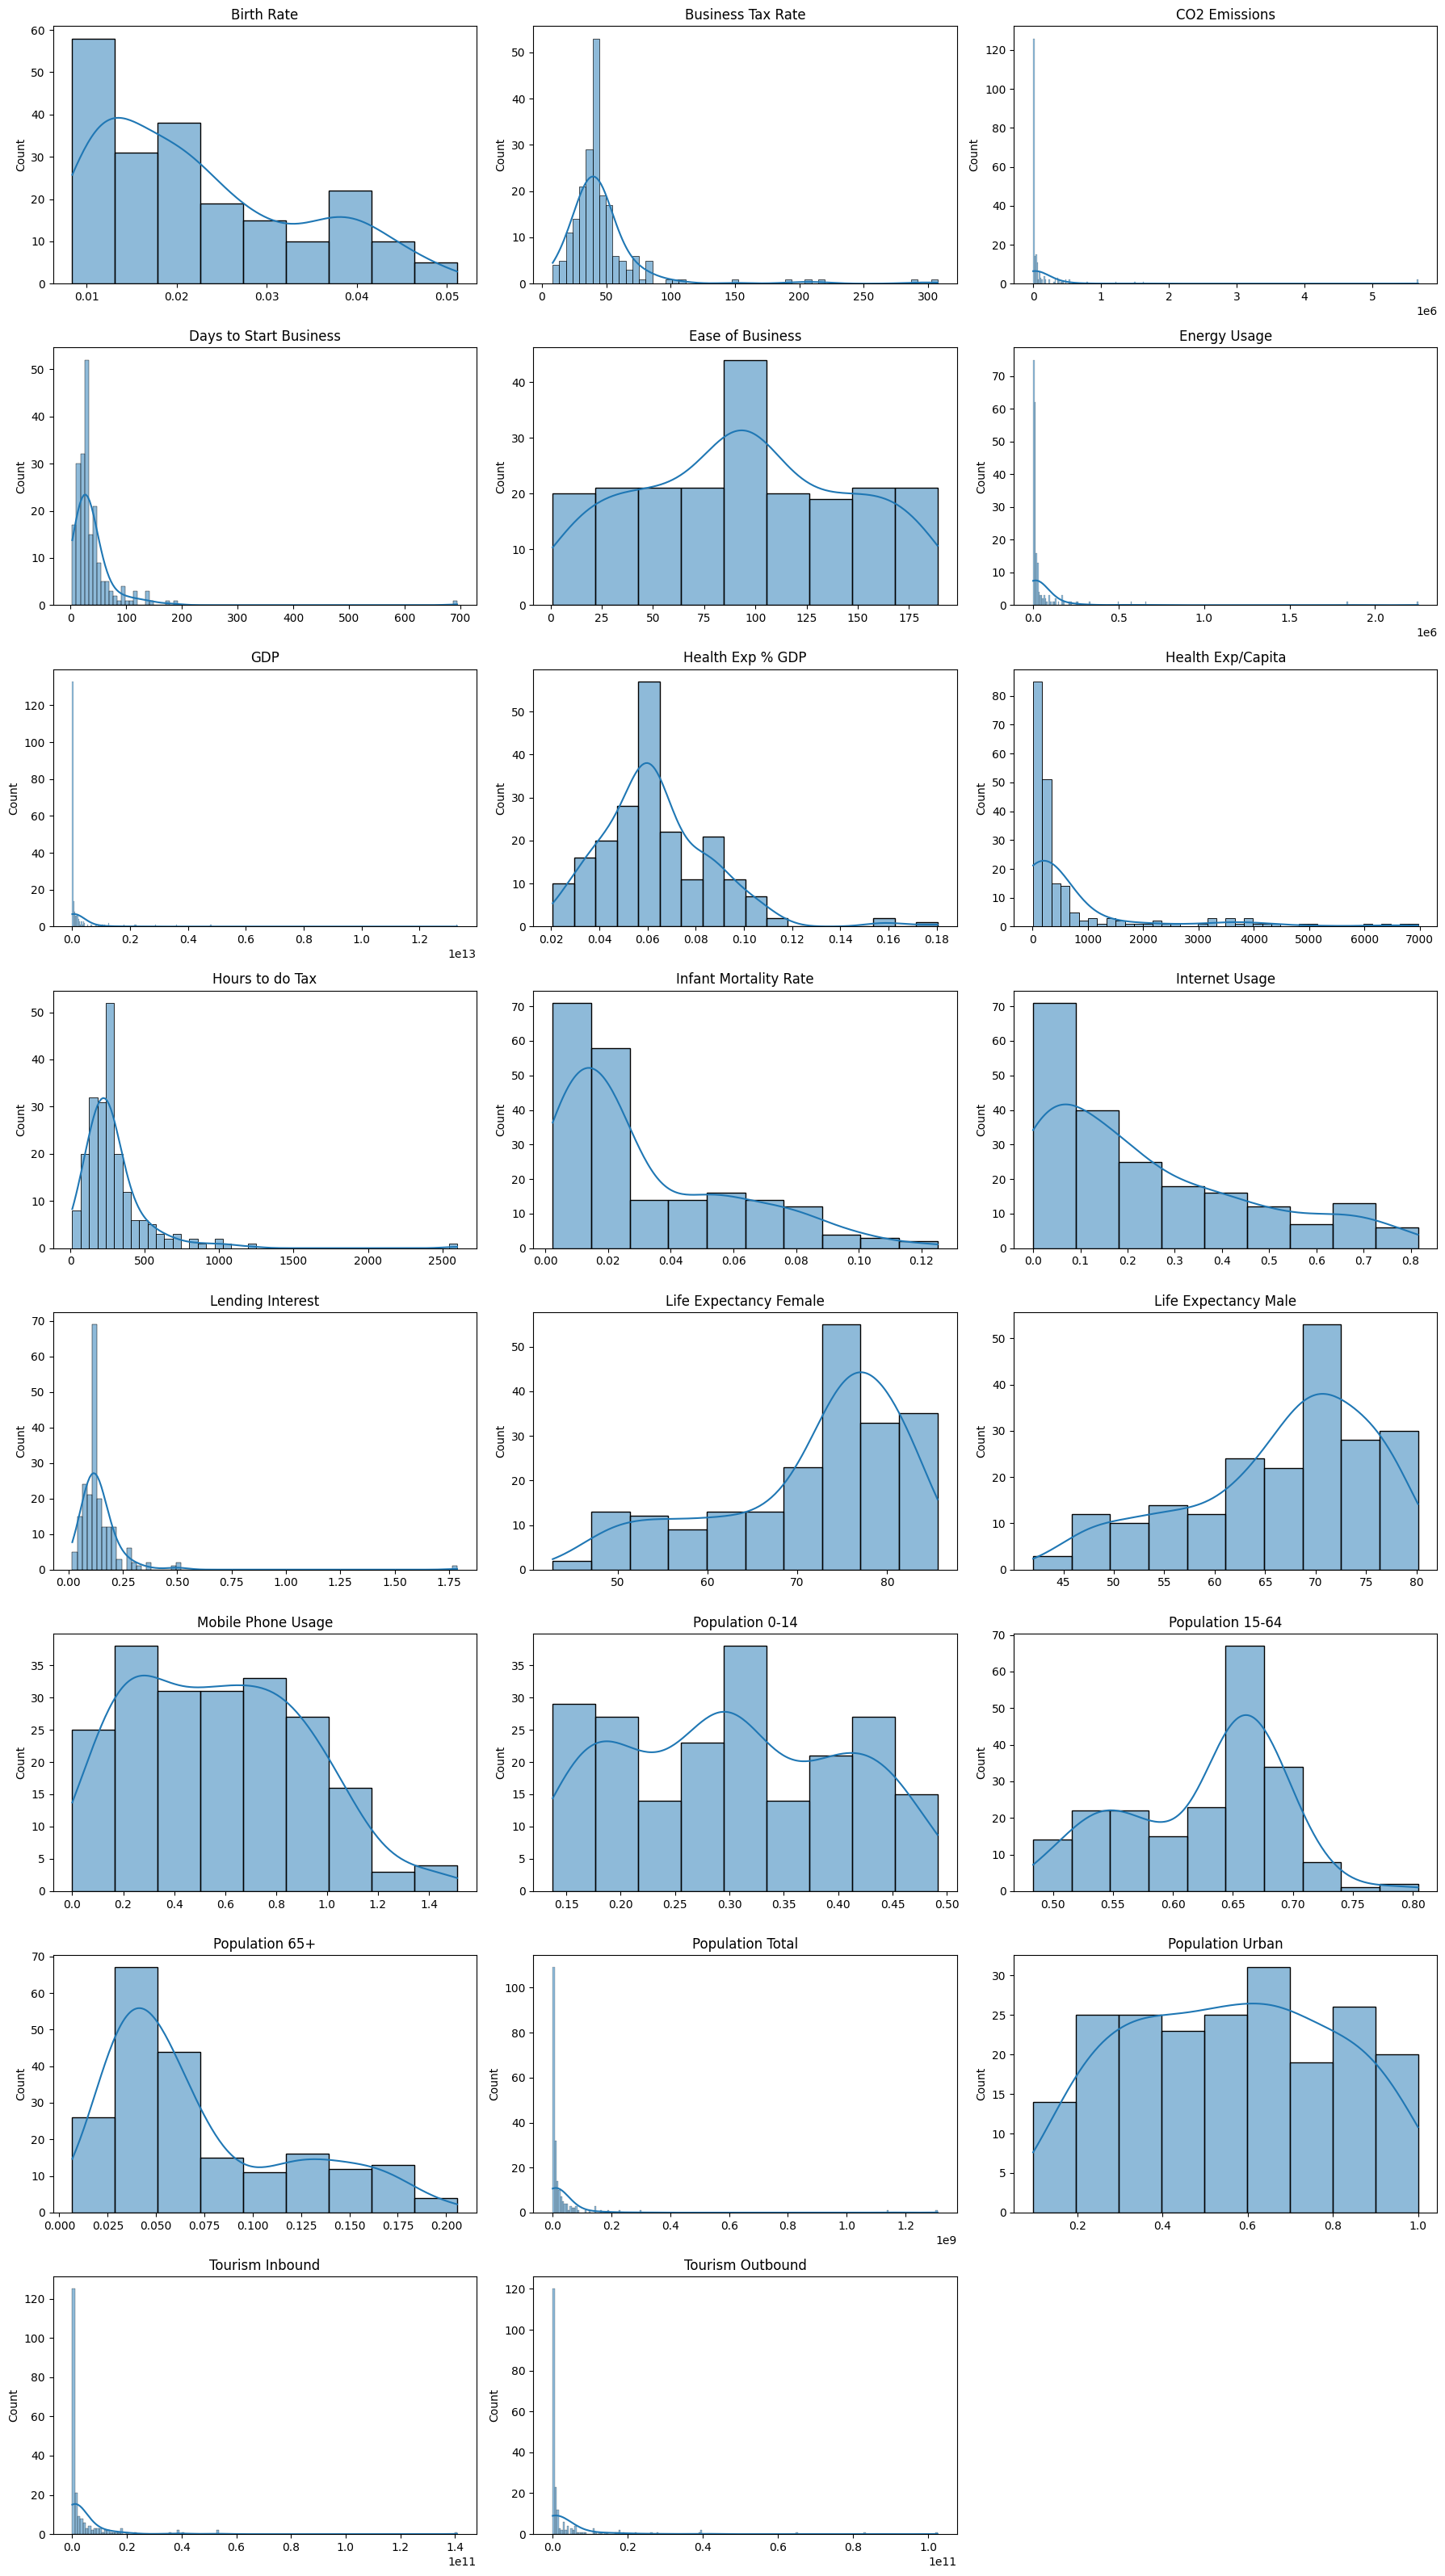

In [32]:
# Plotting distributions of all development indicators

n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(
        country_df[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    
# Hide unused subplots
for i in range(len(feature_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Boxplots for Outlier Inspection

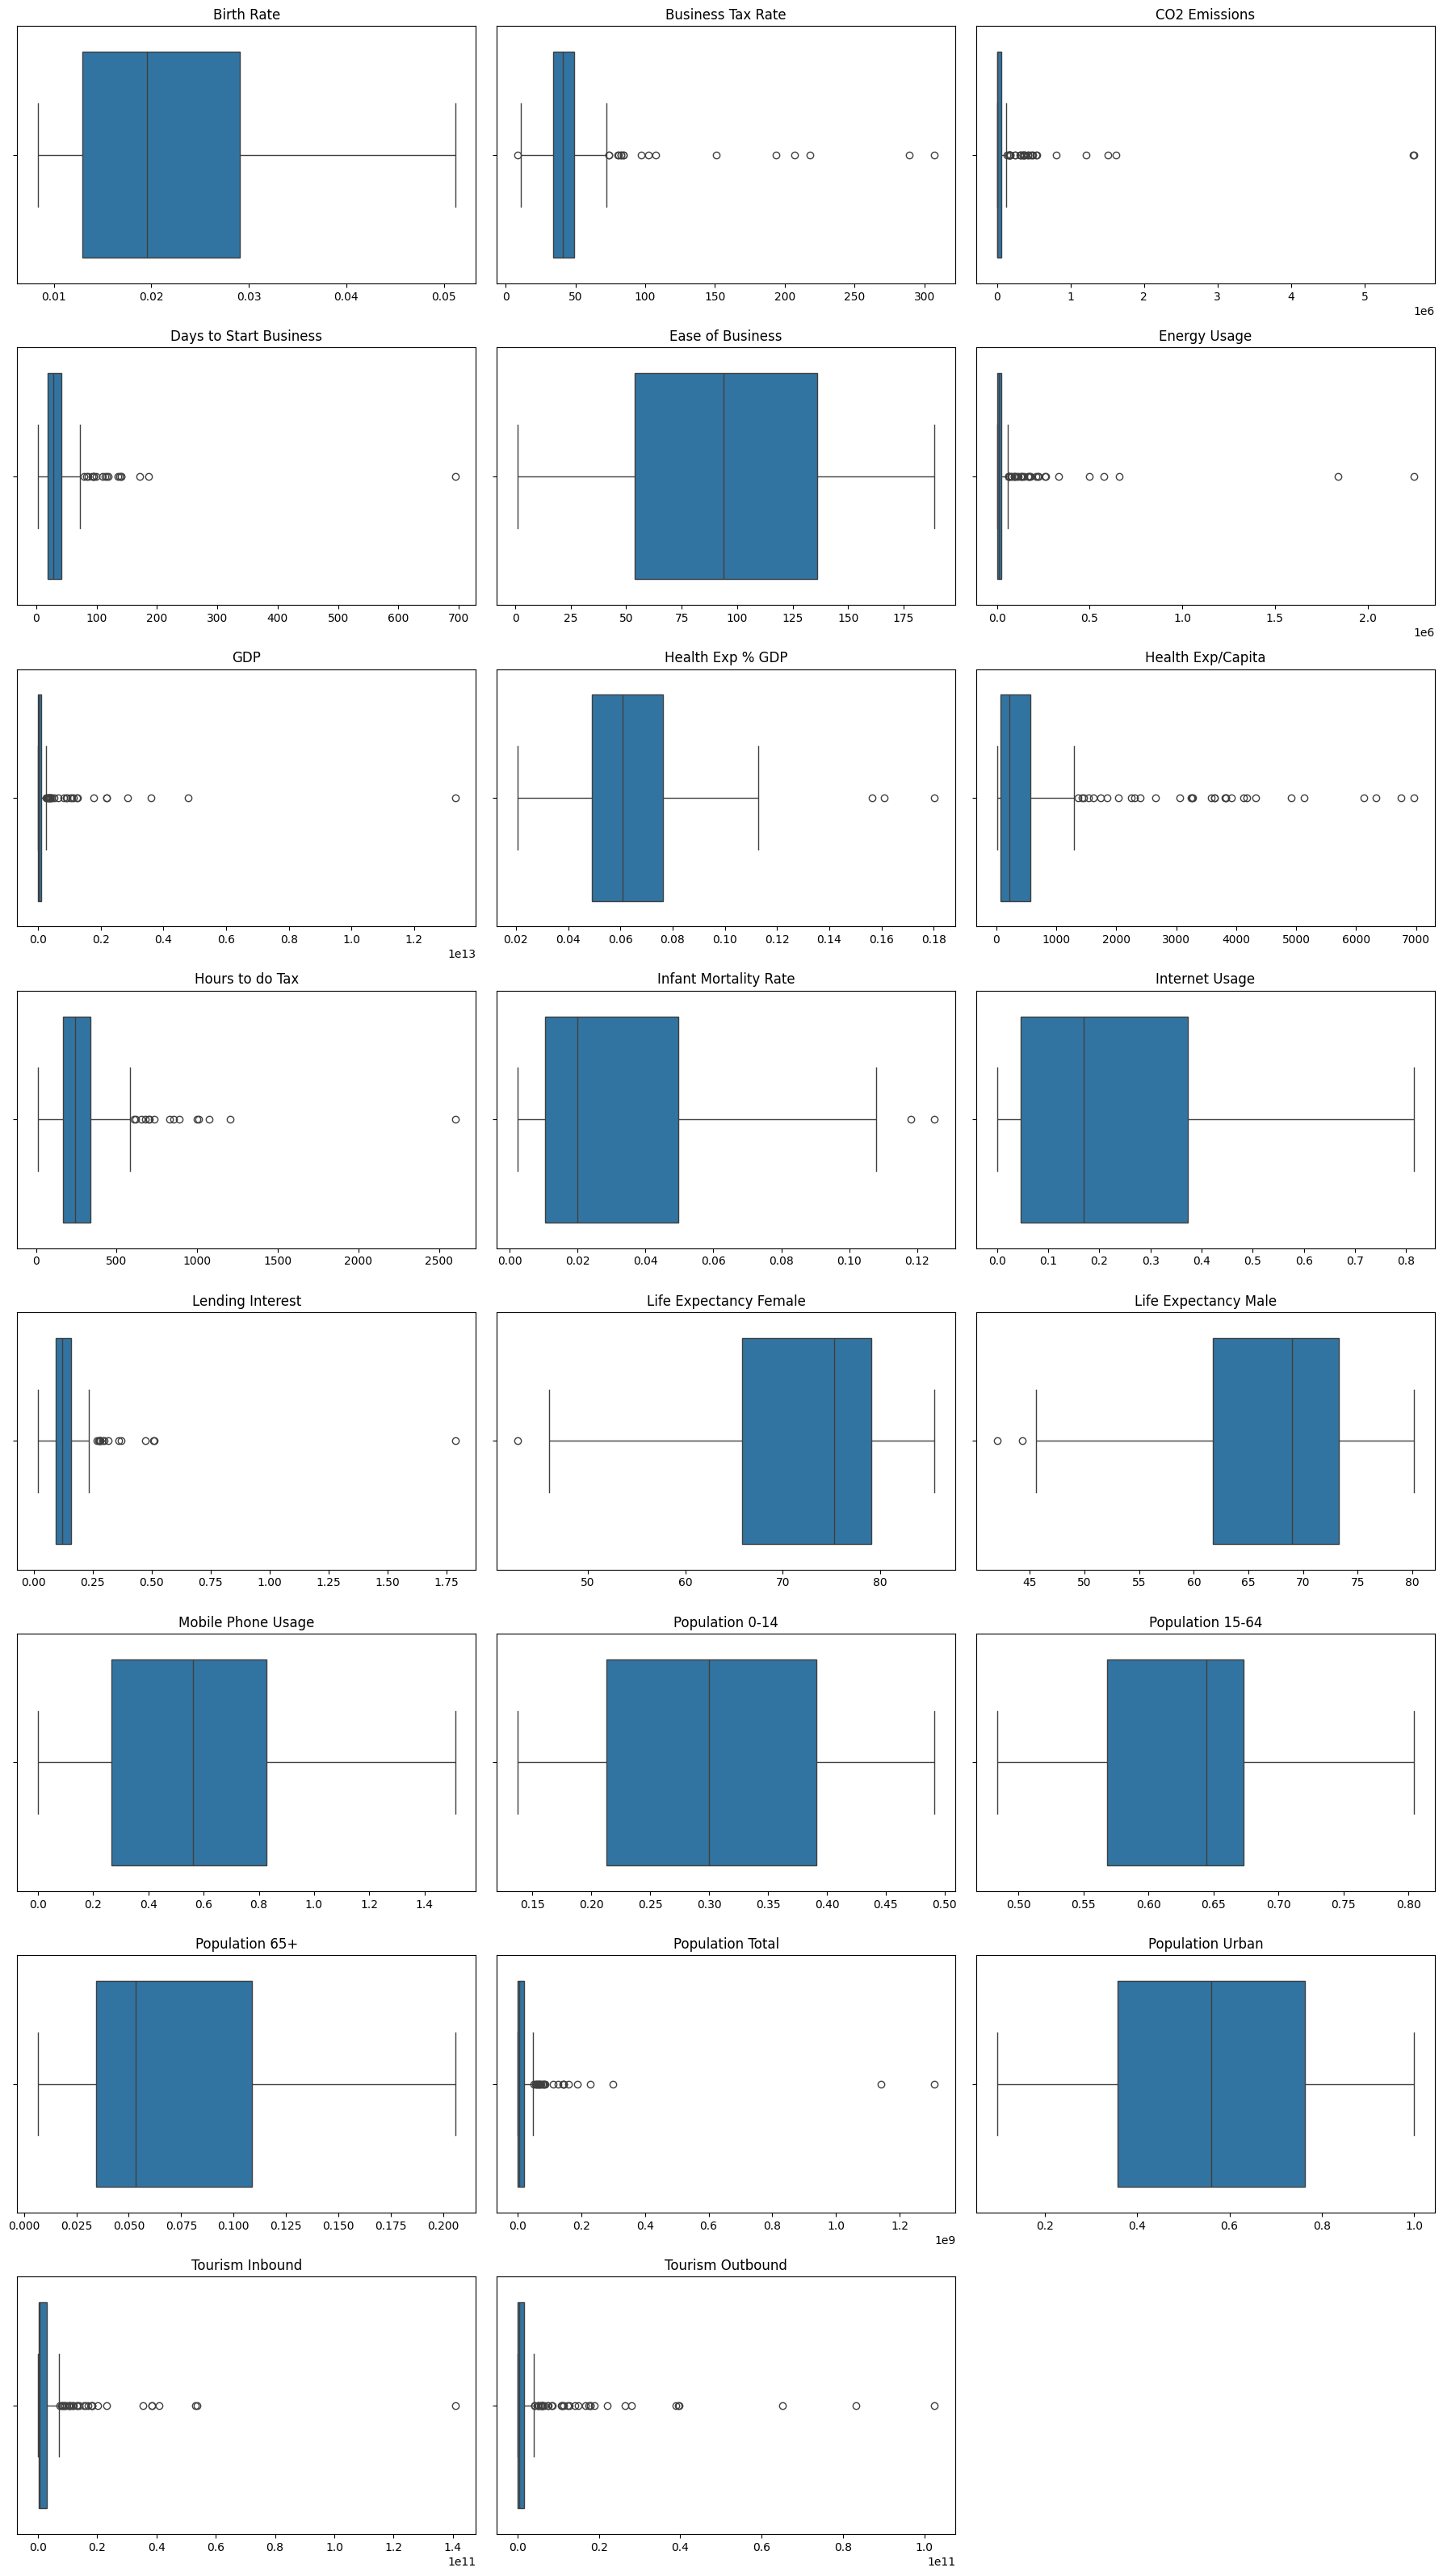

In [33]:
# Boxplots for all development indicators

n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(
        x=country_df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for i in range(len(feature_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation Heatmap

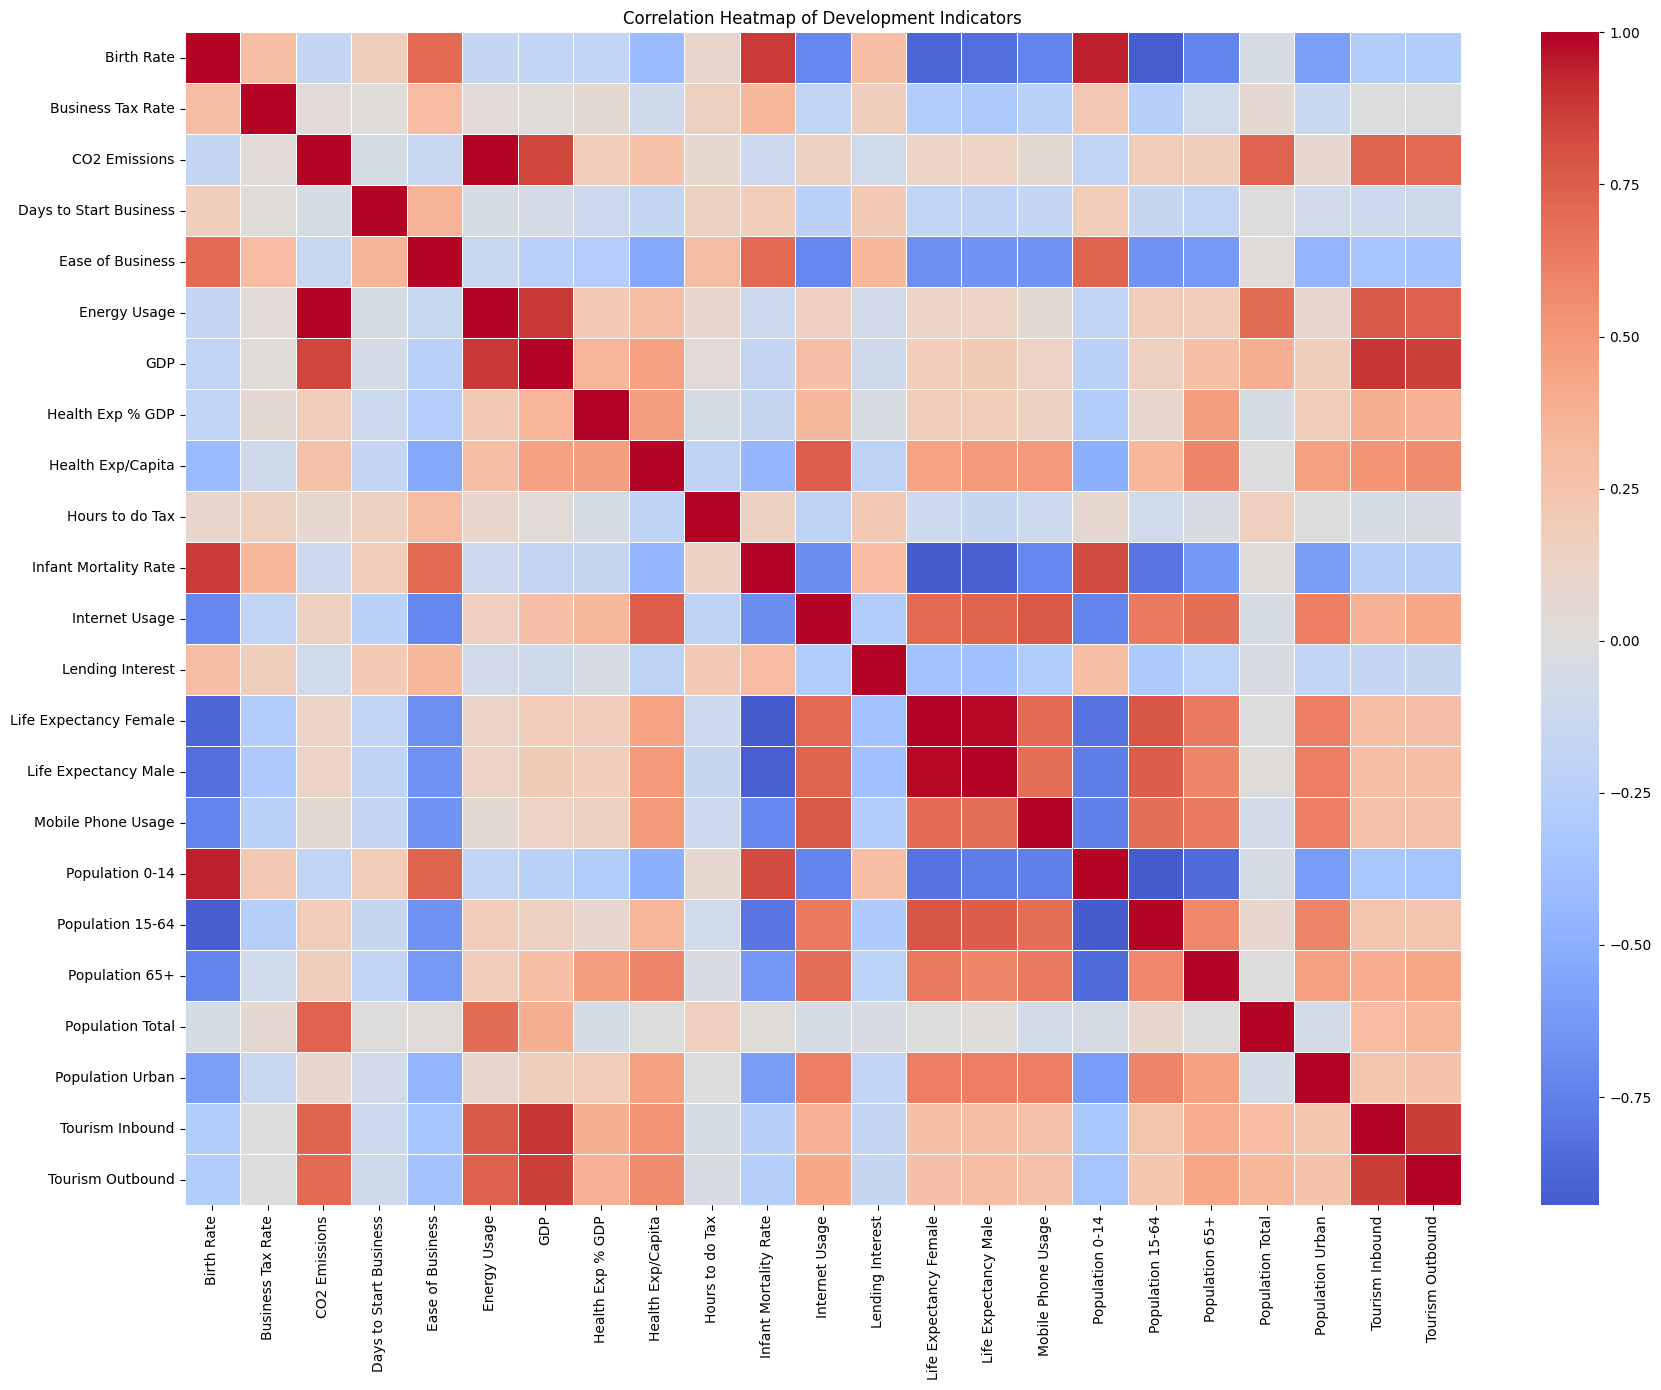

In [34]:
# Correlation matrix
correlation_matrix = country_df[feature_cols].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Development Indicators")
plt.tight_layout()
plt.show()

## Identifying Highly Skewed Features

In [35]:
# Calculating skewness of each feature
skewness = (
    country_df[feature_cols]
    .skew()
    .sort_values(ascending=False)
)

skewness

GDP                       9.771681
Lending Interest          8.850711
Population Total          8.831102
Days to Start Business    8.811665
CO2 Emissions             8.473955
Energy Usage              8.253855
Tourism Inbound           7.294983
Tourism Outbound          5.581481
Hours to do Tax           4.723825
Business Tax Rate         4.619675
Health Exp/Capita         2.720140
Health Exp % GDP          1.286161
Infant Mortality Rate     1.122707
Population 65+            1.021774
Internet Usage            0.904185
Birth Rate                0.708192
Mobile Phone Usage        0.331940
Population 0-14           0.086772
Ease of Business          0.024475
Population Urban          0.017077
Population 15-64         -0.361027
Life Expectancy Male     -0.745097
Life Expectancy Female   -0.932452
dtype: float64

In [36]:
# Displaying features with substantial positive or negative skewness

skewed_features = skewness[abs(skewness) > 1]

print("Features with |skewness| > 1:")
skewed_features

Features with |skewness| > 1:


GDP                       9.771681
Lending Interest          8.850711
Population Total          8.831102
Days to Start Business    8.811665
CO2 Emissions             8.473955
Energy Usage              8.253855
Tourism Inbound           7.294983
Tourism Outbound          5.581481
Hours to do Tax           4.723825
Business Tax Rate         4.619675
Health Exp/Capita         2.720140
Health Exp % GDP          1.286161
Infant Mortality Rate     1.122707
Population 65+            1.021774
dtype: float64

# Log Transformation of Highly Skewed Features

**Skewness Reduction:**

Several development indicators exhibit substantial positive skewness. Variables such as GDP, population, CO₂ emissions, energy usage, and tourism have large differences between countries, resulting in long right-tailed distributions.

Because clustering algorithms are distance-based, extreme skewness can cause a small number of observations to disproportionately influence cluster formation.

To reduce this effect while preserving the relative differences between countries, a logarithmic transformation is applied to highly right-skewed, non-negative variables. The **log1p** transformation is used so that zero-valued observations can also be handled safely.

In [37]:
# Features with substantial positive skewness
log_features = skewness[skewness > 2].index.tolist()

print("Features selected for log transformation:")
print(log_features)

Features selected for log transformation:
['GDP', 'Lending Interest', 'Population Total', 'Days to Start Business', 'CO2 Emissions', 'Energy Usage', 'Tourism Inbound', 'Tourism Outbound', 'Hours to do Tax', 'Business Tax Rate', 'Health Exp/Capita']


In [38]:
# Creating a copy for transformed data
country_transformed = country_df.copy()

# Applying log1p transformation
for col in log_features:
    country_transformed[col] = np.log1p(country_transformed[col])

In [39]:
# Recalculating skewness after transformation
transformed_skewness = (
    country_transformed[feature_cols]
    .skew()
    .sort_values(ascending=False)
)

transformed_skewness

Lending Interest          5.788722
Health Exp % GDP          1.286161
Infant Mortality Rate     1.122707
Population 65+            1.021774
Internet Usage            0.904185
Birth Rate                0.708192
Business Tax Rate         0.703837
Days to Start Business    0.409910
Mobile Phone Usage        0.331940
GDP                       0.246759
Health Exp/Capita         0.241439
Population 0-14           0.086772
CO2 Emissions             0.058103
Ease of Business          0.024475
Population Urban          0.017077
Tourism Outbound         -0.000616
Tourism Inbound          -0.208282
Hours to do Tax          -0.296724
Population 15-64         -0.361027
Population Total         -0.376470
Energy Usage             -0.588598
Life Expectancy Male     -0.745097
Life Expectancy Female   -0.932452
dtype: float64

**Comparing skewness before and after transformation:**

In [40]:
skewness_comparison = pd.DataFrame({
    'Original Skewness': skewness[log_features],
    'Transformed Skewness': transformed_skewness[log_features]
})

skewness_comparison

,Original Skewness,Transformed Skewness
GDP,9.771681,0.246759
Lending Interest,8.850711,5.788722
Population Total,8.831102,-0.376470
Days to Start Business,8.811665,0.409910
CO2 Emissions,8.473955,0.058103
Energy Usage,8.253855,-0.588598
Tourism Inbound,7.294983,-0.208282
Tourism Outbound,5.581481,-0.000616
Hours to do Tax,4.723825,-0.296724
Business Tax Rate,4.619675,0.703837


We observe that **Lending Interest** is still extremely skewed (**8.85** → **5.79**)

## Inspecting Lending Interest

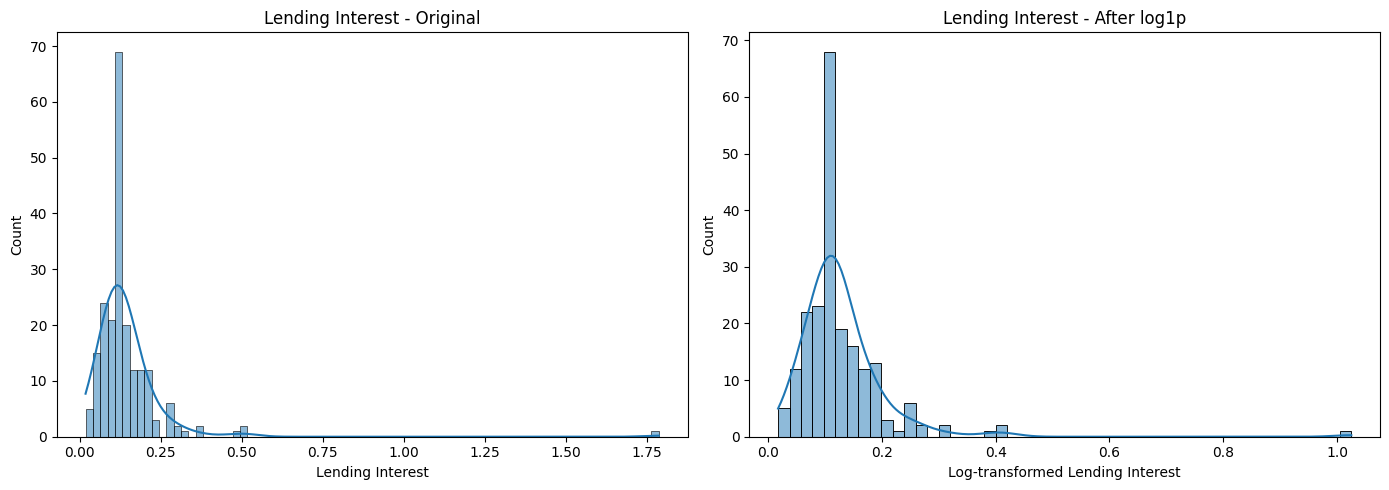

In [41]:
# Inspecting the distribution of Lending Interest after log transformation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    country_df['Lending Interest'],
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Lending Interest - Original')
axes[0].set_xlabel('Lending Interest')

sns.histplot(
    country_transformed['Lending Interest'],
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Lending Interest - After log1p')
axes[1].set_xlabel('Log-transformed Lending Interest')

plt.tight_layout()
plt.show()

In [42]:
# Inspecting the highest Lending Interest values

country_df[
    ['Country', 'Lending Interest']
].sort_values(
    by='Lending Interest',
    ascending=False
).head(15)

,Country,Lending Interest
207,Zimbabwe,1.787286
5,Angola,0.512308
26,Brazil,0.509000
41,"Congo, Dem. Rep.",0.472429
114,Madagascar,0.369154
115,Malawi,0.361462
157,Sao Tome and Principe,0.316923
199,Uruguay,0.297308
145,Paraguay,0.290000
67,"Gambia, The",0.282615


In [43]:
# Descriptive statistics for Lending Interest
country_df['Lending Interest'].describe()

count    208.000000
mean       0.143648
std        0.136348
min        0.017692
25%        0.091891
50%        0.121154
75%        0.159346
max        1.787286
Name: Lending Interest, dtype: float64

# Final Feature Transformation

Creating the actual matrix that will be used by all three clustering algorithms.

**Verify the transformed feature matrix:**

In [44]:
# Preparing the final feature matrix for clustering

X = country_transformed[feature_cols].copy()

print("Feature matrix shape:", X.shape)
print("Number of features:", X.shape[1])
print("Missing values:", X.isnull().sum().sum())

Feature matrix shape: (208, 23)
Number of features: 23
Missing values: 0


# Feature Scaling

The development indicators are measured using different units and scales. For example, GDP and population have very large numerical values, while birth rate, health expenditure as a percentage of GDP, and population proportions have much smaller values.

Since K-Means, Hierarchical Clustering, and DBSCAN rely on distances between observations, variables with larger numerical scales could otherwise dominate the clustering process.

The transformed features are therefore standardized using **StandardScaler**, giving each feature a mean of approximately zero and a standard deviation of approximately one.

In [45]:
# Standardizing the transformed features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Converting back to DataFrame for easier inspection
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_cols,
    index=country_df.index
)

X_scaled_df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,1.856459,-0.261298,-0.542238,-1.650691,1.459621,0.089042,-0.309100,1.201271,-1.239225,0.238530,1.818801,-0.988765,0.212459,-1.213062,-1.127230,-0.928789,1.859360,-2.084446,-1.076681,0.800436,-1.352071,-0.832082,-0.826080
1,-0.698938,0.060317,-0.340732,-0.295275,-0.247966,-0.586227,-0.348340,-0.094777,-0.167713,0.661617,-0.490754,-0.197787,0.040007,0.752306,0.699196,-0.026694,-0.439396,0.434067,0.337482,-0.139393,-0.345745,0.276845,0.338535
2,-0.035916,1.180843,0.988193,-0.183262,1.090938,0.693801,0.801407,-1.073809,-0.314840,0.981593,-0.135438,-0.752049,-0.569008,0.020834,0.191856,-0.230128,-0.099348,0.577377,-0.582615,0.937554,0.336905,-0.390696,-0.034898
3,-0.177499,-0.011832,-0.056498,-0.044999,-0.015113,0.089042,-0.059547,-0.124246,-0.001635,0.040498,-0.411491,-0.301712,-0.174867,0.375487,0.259501,-1.676767,-0.023867,0.296042,-0.388228,-1.861046,1.299108,0.011815,-0.052332
4,-1.067859,-0.011832,-1.145255,-0.044999,-0.015113,0.089042,-0.954033,-0.019467,1.519610,0.040498,-1.015529,1.262922,-0.174867,0.375487,0.259501,0.380173,-0.023867,0.296042,-0.388228,-1.735423,1.370651,0.011815,-0.052332


In [46]:
# Verifying scaling
scaling_check = pd.DataFrame({
    'Mean': X_scaled_df.mean(),
    'Std': X_scaled_df.std()
})

scaling_check

,Mean,Std
Birth Rate,-5.978124e-17,1.002413
Business Tax Rate,-1.503071e-15,1.002413
CO2 Emissions,4.996004e-16,1.002413
Days to Start Business,-4.697097e-17,1.002413
Ease of Business,-1.537232e-16,1.002413
Energy Usage,-1.793437e-16,1.002413
GDP,-1.050442e-15,1.002413
Health Exp % GDP,-5.124106e-17,1.002413
Health Exp/Capita,3.843080e-16,1.002413
Hours to do Tax,1.793437e-16,1.002413


In [47]:
# Final validation before clustering

print("Shape:", X_scaled_df.shape)
print("Missing values:", X_scaled_df.isnull().sum().sum())
print("Infinite values:", np.isinf(X_scaled_df.values).sum())

Shape: (208, 23)
Missing values: 0
Infinite values: 0


# Implementing Clustering Algorithms

## K-Means Clustering

K-Means clustering partitions countries into a predefined number of clusters by minimizing the within-cluster sum of squared distances. Since K-Means requires the number of clusters to be specified in advance, multiple values of K are evaluated to identify an appropriate number of clusters.

The **Elbow Method** is used to examine the reduction in within-cluster sum of squares (WCSS), while the **Silhouette Score** is used to evaluate how well-separated and cohesive the resulting clusters are.

In [48]:
# Evaluating K-Means for different numbers of clusters

k_values = range(2, 11)

wcss = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

**Elbow Curve Plot:**

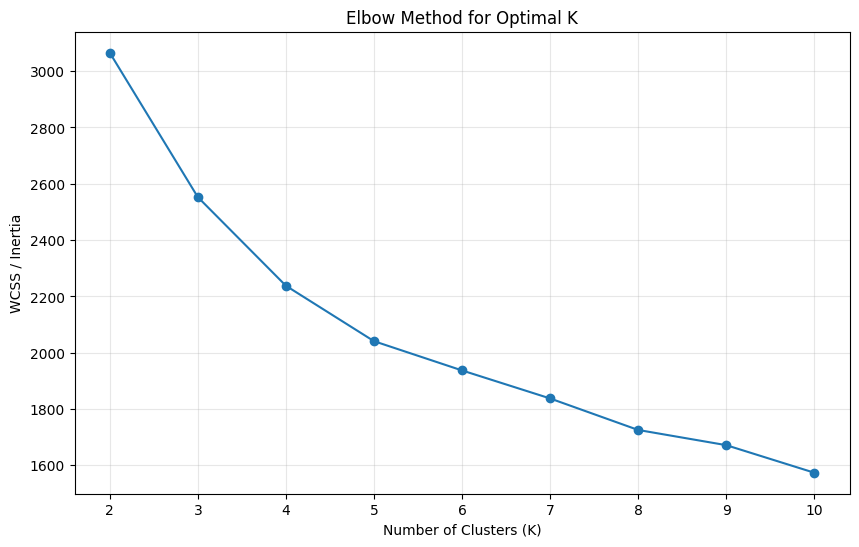

In [49]:
# Elbow Method

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.show()

**Silhouette Scores Plot:**

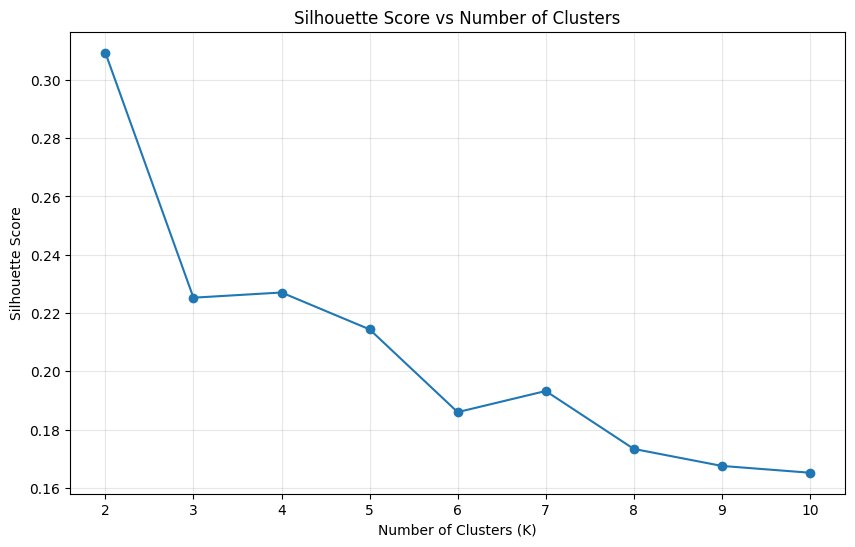

In [50]:
# Silhouette Score for different K values

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")

plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.show()

**Comparing K-Means evaluation metrics:**

In [51]:
kmeans_evaluation = pd.DataFrame({
    'K': list(k_values),
    'WCSS': wcss,
    'Silhouette Score': silhouette_scores
})

kmeans_evaluation

,K,WCSS,Silhouette Score
0,2,3065.524694,0.309315
1,3,2552.706917,0.225275
2,4,2237.938037,0.227050
3,5,2041.089344,0.214405
4,6,1937.144100,0.186004
5,7,1837.663215,0.193259
6,8,1725.721253,0.173389
7,9,1671.767093,0.167551
8,10,1573.873330,0.165221


### Fitting the Final K-Means Model

**Final K-Means Model:**

Based on the evaluation of multiple cluster counts, **K = 2** is selected for the final K-Means model because it produces the highest Silhouette Score among the tested values.

The final model is fitted using the standardized development indicators.

In [52]:
# Fitting the final K-Means model with K = 2

kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_scaled)

In [53]:
# Storing cluster labels
country_df['KMeans_Cluster'] = kmeans_labels

print("K-Means Silhouette Score:",
      silhouette_score(X_scaled, kmeans_labels))

K-Means Silhouette Score: 0.3093149993402546


**Cluster Sizes:**

In [54]:
# Number of countries in each K-Means cluster

kmeans_cluster_sizes = (
    country_df['KMeans_Cluster']
    .value_counts()
    .sort_index()
)

kmeans_cluster_sizes

KMeans_Cluster
0     80
1    128
Name: count, dtype: int64

**Visualization:**

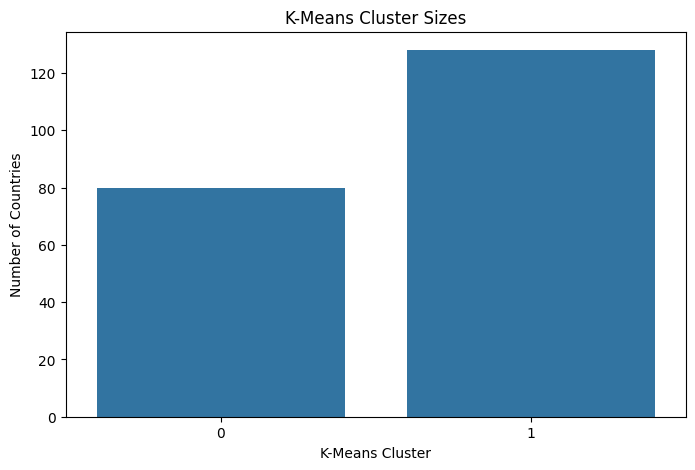

In [55]:
# Visualizing K-Means cluster sizes

plt.figure(figsize=(8, 5))

sns.barplot(
    x=kmeans_cluster_sizes.index,
    y=kmeans_cluster_sizes.values
)

plt.xlabel("K-Means Cluster")
plt.ylabel("Number of Countries")
plt.title("K-Means Cluster Sizes")

plt.show()

### K-Means Cluster Profiling

Creating a separate profile dataset:

In [56]:
# Calculating mean development indicators for each K-Means cluster

kmeans_profile = (
    country_df
    .groupby('KMeans_Cluster')[feature_cols]
    .mean()
)

kmeans_profile

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,,,
0,0.034136,57.233237,9635.407923,56.894995,136.462500,9122.460417,1.414935e+10,0.059812,89.939685,300.538393,0.059671,0.045313,0.192896,60.992308,57.808654,0.264791,0.406186,0.557989,0.035790,1.645374e+07,0.368272,2.426291e+08,2.636142e+08
1,0.015190,41.565412,209771.957789,28.180667,68.726562,83472.463205,3.886288e+11,0.066111,1136.847356,288.128571,0.014025,0.355549,0.112869,77.902333,72.158395,0.761768,0.238047,0.667317,0.094464,4.083451e+07,0.684583,6.911051e+09,6.319060e+09


Now, we create a standardized version of the cluster profiles. This makes it easier to see which features are relatively high or low in each cluster.

In [57]:
# Standardizing cluster profiles for comparison

profile_scaler = StandardScaler()

kmeans_profile_scaled = pd.DataFrame(
    profile_scaler.fit_transform(kmeans_profile),
    columns=feature_cols,
    index=kmeans_profile.index
)

kmeans_profile_scaled

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,,,
0,1.0,1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,-1.0,-1.0,1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Heatmap of Cluster Profiles:**

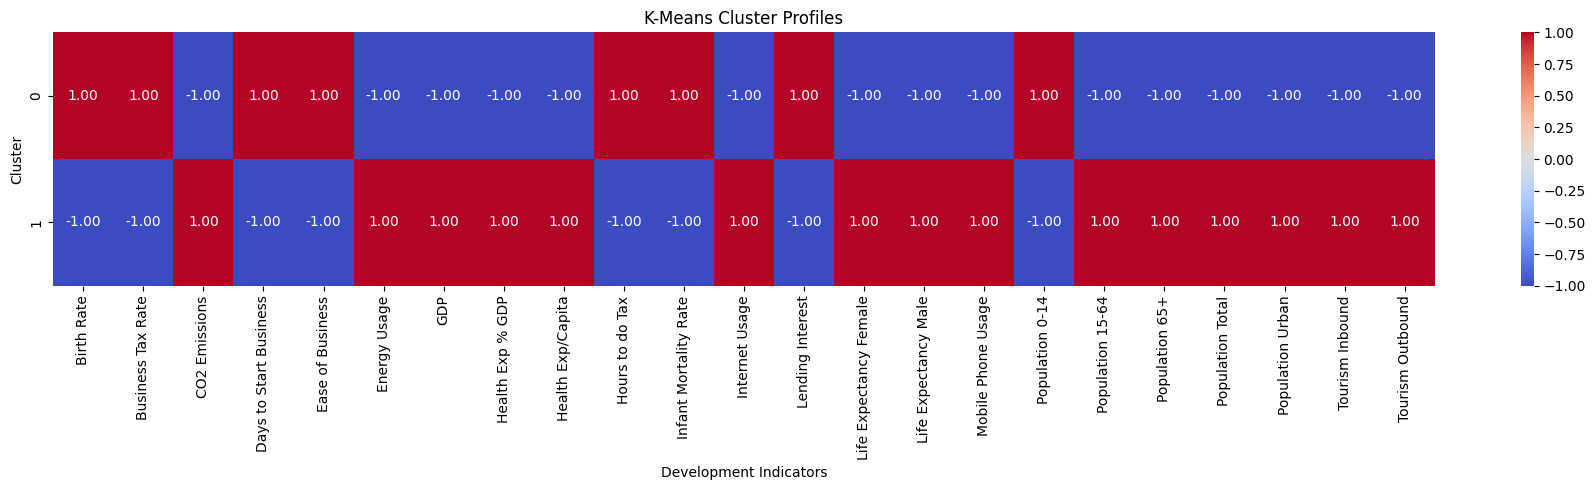

In [58]:
# Heatmap of standardized K-Means cluster profiles

plt.figure(figsize=(18, 5))

sns.heatmap(
    kmeans_profile_scaled,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f'
)

plt.title("K-Means Cluster Profiles")
plt.xlabel("Development Indicators")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

**Countries in Each Cluster:**

In [59]:
# Displaying countries belonging to each K-Means cluster

for cluster in sorted(country_df['KMeans_Cluster'].unique()):
    print(f"\nCluster {cluster}")
    print("-" * 50)
    
    countries = (
        country_df[
            country_df['KMeans_Cluster'] == cluster
        ]['Country']
        .sort_values()
        .tolist()
    )
    
    print(", ".join(countries))


Cluster 0
--------------------------------------------------
Afghanistan, Angola, Bangladesh, Belize, Benin, Bhutan, Bolivia, Botswana, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Djibouti, Equatorial Guinea, Eritrea, Ethiopia, Fiji, Gabon, Gambia, The, Ghana, Grenada, Guatemala, Guinea, Guinea-Bissau, Guyana, Haiti, Honduras, Iraq, Kenya, Kiribati, Kyrgyz Republic, Lao PDR, Lesotho, Liberia, Madagascar, Malawi, Mali, Marshall Islands, Mauritania, Micronesia, Fed. Sts., Mongolia, Mozambique, Myanmar, Namibia, Nepal, Nicaragua, Niger, Nigeria, Pakistan, Papua New Guinea, Paraguay, Rwanda, Samoa, Sao Tome and Principe, Senegal, Sierra Leone, Solomon Islands, Somalia, South Sudan, Sudan, Suriname, Swaziland, Tajikistan, Tanzania, Timor-Leste, Togo, Tonga, Turkmenistan, Uganda, Uzbekistan, Vanuatu, Yemen, Rep., Zambia, Zimbabwe

Cluster 1
--------------------------------------------------
Albania, Algeri

### K-Means PCA Visualization

The original dataset contains 23 development indicators, making direct visualization of the complete feature space difficult. **Principal Component Analysis (PCA)** is therefore used to project the standardized feature space into two dimensions for visualization.

**Note:** PCA is being used only for visualization. The K-Means model was trained using all 23 standardized features.

In [60]:
# PCA for 2D visualization

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_kmeans_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_kmeans_df['KMeans_Cluster'] = kmeans_labels

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by 2 components:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.50029425 0.16211841]

Total variance explained by 2 components: 0.6624126640678285


**Visualization:**

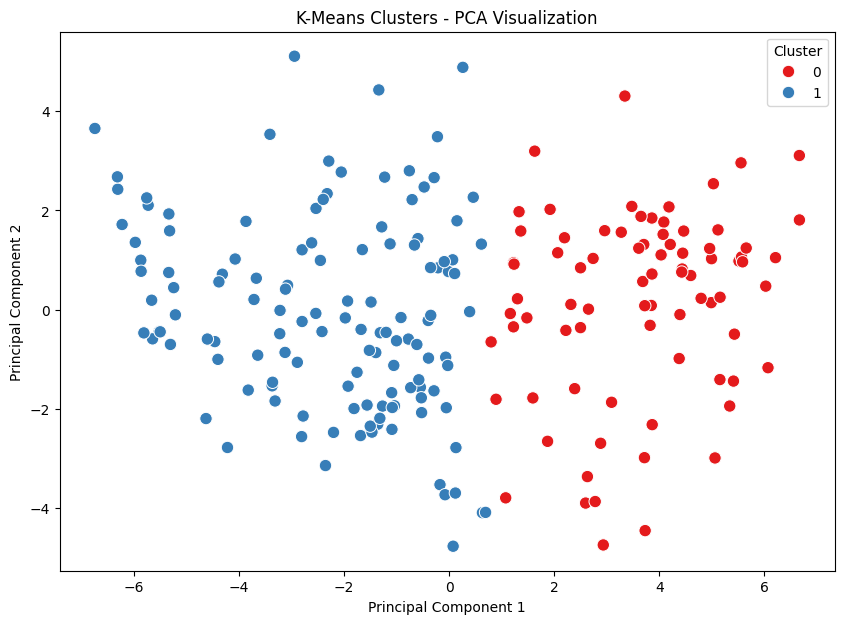

In [61]:
# Visualizing K-Means clusters in PCA space

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_kmeans_df,
    x='PC1',
    y='PC2',
    hue='KMeans_Cluster',
    palette='Set1',
    s=80
)

plt.title("K-Means Clusters - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

## Hierarchical Clustering

**Hierarchical (Agglomerative) Clustering**

Hierarchical clustering builds a hierarchy of observations by progressively merging similar countries. A dendrogram is used to visualize the hierarchical structure and identify potential cluster groupings.

Four linkage methods are considered:

- **Single linkage:** distance between the closest observations in two clusters.
- **Complete linkage:** distance between the farthest observations.
- **Average linkage:** average distance between observations in two clusters.
- **Ward linkage:** minimizes the increase in within-cluster variance during merging.

**Dendrogram Plot:**

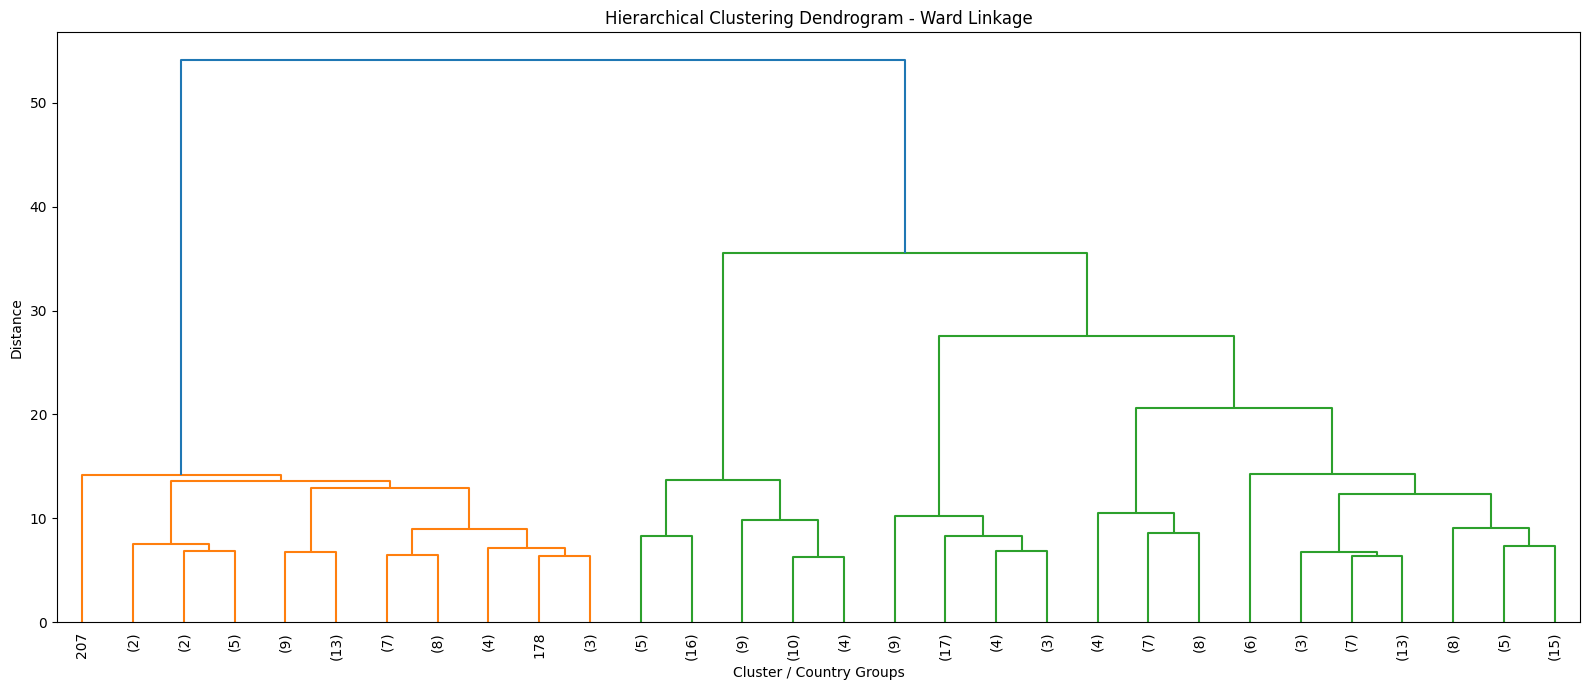

In [62]:
# Ward-linkage dendrogram

plt.figure(figsize=(16, 7))

linkage_matrix = linkage(
    X_scaled,
    method='ward'
)

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Cluster / Country Groups")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

**Evaluating Different Linkage Methods:**

In [63]:
# Evaluating hierarchical clustering across linkage methods and cluster counts

linkage_methods = [
    'single',
    'complete',
    'average',
    'ward'
]

hc_results = []

for linkage_method in linkage_methods:
    
    for k in range(2, 11):
        
        hc = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage_method
        )
        
        labels = hc.fit_predict(X_scaled)
        
        score = silhouette_score(
            X_scaled,
            labels
        )
        
        hc_results.append({
            'Linkage': linkage_method,
            'K': k,
            'Silhouette Score': score
        })

hc_results_df = pd.DataFrame(hc_results)

hc_results_df

,Linkage,K,Silhouette Score
0,single,2,0.471354
1,single,3,0.294420
2,single,4,0.247345
3,single,5,0.222438
4,single,6,0.047913
5,single,7,0.046732
6,single,8,0.008008
7,single,9,-0.016113
8,single,10,-0.030827
9,complete,2,0.294261


**Finding the Best Configuration for Each Linkage:**

In [64]:
# Best cluster count for each linkage method

best_hc_by_linkage = (
    hc_results_df
    .sort_values(
        'Silhouette Score',
        ascending=False
    )
    .groupby('Linkage')
    .head(1)
    .sort_values(
        'Silhouette Score',
        ascending=False
    )
    .reset_index(drop=True)
)

best_hc_by_linkage

,Linkage,K,Silhouette Score
0,single,2,0.471354
1,average,2,0.471354
2,complete,2,0.294261
3,ward,2,0.293445


**Plotting Silhouette Score by K:**

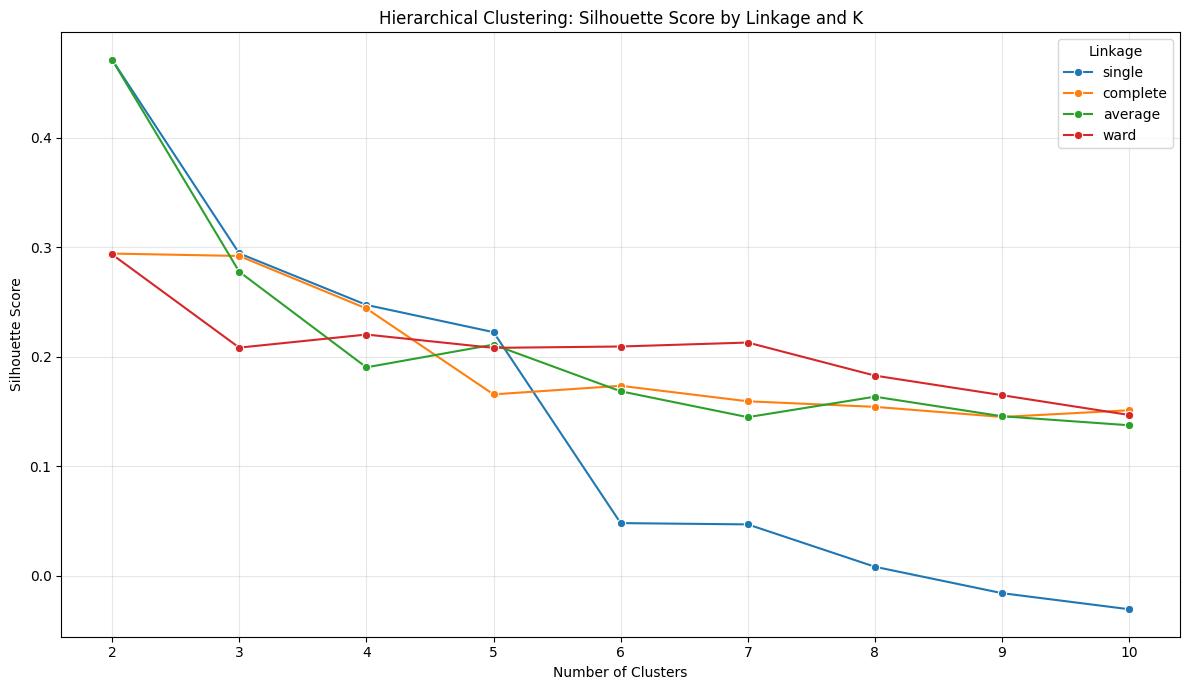

In [65]:
# Comparing silhouette scores across linkage methods

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=hc_results_df,
    x='K',
    y='Silhouette Score',
    hue='Linkage',
    marker='o'
)

plt.title("Hierarchical Clustering: Silhouette Score by Linkage and K")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:**

**Single** and **Average** linkage produce exactly the same score at K=2.

### Comparing Single vs Average Linkage

**Comparing the Best Hierarchical Configurations**

Single and Average linkage both achieve the highest Silhouette Score of 0.471354 with two clusters. Their cluster assignments and sizes are therefore compared before selecting the final hierarchical model.

In [66]:
# Fitting the two best hierarchical clustering configurations

hc_single = AgglomerativeClustering(
    n_clusters=2,
    linkage='single'
)

hc_average = AgglomerativeClustering(
    n_clusters=2,
    linkage='average'
)

single_labels = hc_single.fit_predict(X_scaled)
average_labels = hc_average.fit_predict(X_scaled)

print("Single Linkage Silhouette:",
      silhouette_score(X_scaled, single_labels))

print("Average Linkage Silhouette:",
      silhouette_score(X_scaled, average_labels))

Single Linkage Silhouette: 0.47135438958826537
Average Linkage Silhouette: 0.47135438958826537


In [67]:
# Comparing cluster sizes

single_sizes = pd.Series(single_labels).value_counts().sort_index()
average_sizes = pd.Series(average_labels).value_counts().sort_index()

cluster_size_comparison = pd.DataFrame({
    'Single Linkage': single_sizes,
    'Average Linkage': average_sizes
})

cluster_size_comparison

,Single Linkage,Average Linkage
0,207,207
1,1,1


In [68]:
# Checking whether Single and Average linkage produce identical partitions

print(
    "Identical cluster assignments:",
    np.array_equal(single_labels, average_labels)
)

Identical cluster assignments: True


In [69]:
# Comparing the actual partition using a contingency table

pd.crosstab(
    single_labels,
    average_labels
)

col_0,0,1
row_0,,
0,207,0
1,0,1


### Evaluating Hierarchical Cluster Balance

Although Single and Average linkage produced the highest Silhouette Score, both methods resulted in a highly imbalanced solution containing one very large cluster and one singleton cluster. Therefore, cluster size and interpretability are considered alongside the Silhouette Score when selecting the final hierarchical clustering model.

In [70]:
# Comparing cluster sizes for all four linkage methods at K = 2

linkage_models = {}

for method in ['single', 'average', 'complete', 'ward']:
    
    model = AgglomerativeClustering(
        n_clusters=2,
        linkage=method
    )
    
    labels = model.fit_predict(X_scaled)
    
    linkage_models[method] = labels


cluster_balance = pd.DataFrame({
    method: pd.Series(labels).value_counts().sort_index()
    for method, labels in linkage_models.items()
}).T

cluster_balance.columns = ['Cluster 0', 'Cluster 1']

cluster_balance

,Cluster 0,Cluster 1
single,207,1
average,207,1
complete,82,126
ward,153,55


In [71]:
# Calculating the size of the smaller cluster as a percentage of all countries

balance_summary = []

for method, labels in linkage_models.items():
    
    counts = pd.Series(labels).value_counts()
    
    smaller_cluster_pct = (
        counts.min() / len(labels)
    ) * 100
    
    balance_summary.append({
        'Linkage': method,
        'Silhouette Score': silhouette_score(X_scaled, labels),
        'Cluster 0 Size': counts.get(0, 0),
        'Cluster 1 Size': counts.get(1, 0),
        'Smaller Cluster (%)': smaller_cluster_pct
    })

balance_summary = pd.DataFrame(balance_summary)

balance_summary.sort_values(
    'Silhouette Score',
    ascending=False
)

,Linkage,Silhouette Score,Cluster 0 Size,Cluster 1 Size,Smaller Cluster (%)
0,single,0.471354,207,1,0.480769
1,average,0.471354,207,1,0.480769
2,complete,0.294261,82,126,39.423077
3,ward,0.293445,153,55,26.442308


In [72]:
# Identifying the country isolated by Single Linkage

single_cluster_df = pd.DataFrame({
    'Country': country_df['Country'],
    'Cluster': single_labels
})

single_cluster_df[
    single_cluster_df['Cluster'] == 1
]

,Country,Cluster
207,Zimbabwe,1


### Final Hierarchical Clustering Model

Although Single and Average linkage achieved the highest Silhouette Score, both produced a highly imbalanced solution in which one country was isolated from the remaining 207 countries. Such a partition provides limited value for meaningful country segmentation.

Complete and Ward linkage produced substantially more balanced clusters. Complete linkage with two clusters was selected as the final hierarchical clustering model because it achieved a slightly higher Silhouette Score than Ward linkage while also producing more balanced cluster sizes.

In [73]:
# Fitting final Hierarchical Clustering model

hc_final = AgglomerativeClustering(
    n_clusters=2,
    linkage='complete'
)

hc_labels = hc_final.fit_predict(X_scaled)

country_df['HC_Cluster'] = hc_labels

print(
    "Hierarchical Clustering Silhouette Score:",
    silhouette_score(X_scaled, hc_labels)
)

Hierarchical Clustering Silhouette Score: 0.2942613434678023


In [74]:
# Final hierarchical cluster sizes

hc_cluster_sizes = (
    country_df['HC_Cluster']
    .value_counts()
    .sort_index()
)

hc_cluster_sizes

HC_Cluster
0     82
1    126
Name: count, dtype: int64

**Profiling the final hierarchical clusters:**

In [75]:
# Profiling the final hierarchical clusters using original-scale features

hc_profile_final = (
    country_df
    .groupby('HC_Cluster')[feature_cols]
    .mean()
)

hc_profile_final

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
HC_Cluster,,,,,,,,,,,,,,,,,,,,,,,
0,0.03329,56.336542,9925.972253,55.333532,134.500000,9087.651423,1.484847e+10,0.058447,113.640969,289.368249,0.057084,0.065101,0.182004,61.612315,58.510660,0.301860,0.399891,0.562532,0.037502,1.682064e+07,0.362678,2.933463e+08,2.773033e+08
1,0.01544,41.900280,212759.631000,28.741075,68.928571,84675.275452,3.941180e+11,0.067099,1138.040293,295.201049,0.014984,0.347595,0.118687,77.767249,71.929308,0.745532,0.239474,0.666096,0.094281,4.098274e+07,0.693244,6.983893e+09,6.406269e+09


In [76]:
# Displaying countries in each final hierarchical cluster

for cluster in sorted(country_df['HC_Cluster'].unique()):
    
    print(f"\nCluster {cluster}")
    print("-" * 50)
    
    countries = (
        country_df[
            country_df['HC_Cluster'] == cluster
        ]['Country']
        .sort_values()
        .tolist()
    )
    
    print(", ".join(countries))


Cluster 0
--------------------------------------------------
Afghanistan, Angola, Antigua and Barbuda, Bangladesh, Belize, Benin, Bhutan, Bolivia, Botswana, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Djibouti, Dominica, Equatorial Guinea, Eritrea, Ethiopia, Fiji, Gabon, Gambia, The, Ghana, Grenada, Guinea, Guinea-Bissau, Guyana, Haiti, Iraq, Kenya, Kiribati, Lao PDR, Lesotho, Liberia, Madagascar, Malawi, Maldives, Mali, Marshall Islands, Mauritania, Micronesia, Fed. Sts., Mozambique, Myanmar, Namibia, Nepal, Niger, Nigeria, Pakistan, Papua New Guinea, Philippines, Rwanda, Samoa, Sao Tome and Principe, Senegal, Seychelles, Sierra Leone, Solomon Islands, Somalia, South Sudan, St. Kitts and Nevis, St. Lucia, St. Vincent and the Grenadines, Sudan, Suriname, Swaziland, Syrian Arab Republic, Tajikistan, Tanzania, Timor-Leste, Togo, Tonga, Uganda, Uzbekistan, Vanuatu, Yemen, Rep., Zambia, Zimbabwe

Cluster

**PCA visualization:**

In [77]:
# Creating PCA dataframe for hierarchical clustering

pca_hc_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_hc_df['HC_Cluster'] = hc_labels

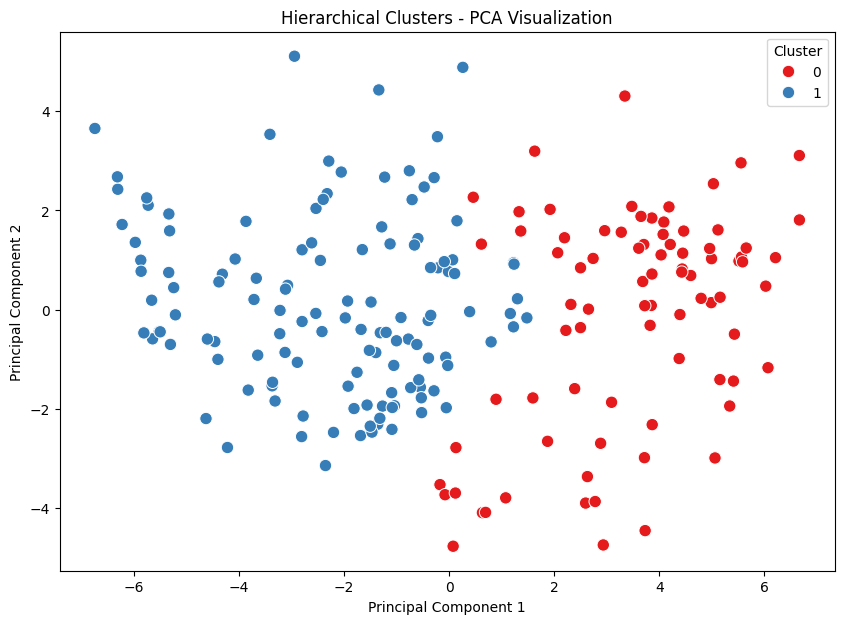

In [78]:
# Visualizing Hierarchical clusters in PCA space

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_hc_df,
    x='PC1',
    y='PC2',
    hue='HC_Cluster',
    palette='Set1',
    s=80
)

plt.title("Hierarchical Clusters - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

## DBSCAN

**Importing nearest-neighbor tool:**

In [79]:
from sklearn.neighbors import NearestNeighbors

**DBSCAN Parameter Selection:**

- **eps** — the maximum distance between two observations for them to be considered neighbors.
- **min_samples** — the minimum number of neighboring observations required to form a dense region.

Since DBSCAN does not require the number of clusters to be specified beforehand, parameter selection is performed using nearest-neighbor distance analysis and subsequent evaluation using Silhouette Score and cluster composition.

**K-Distance Analysis:**

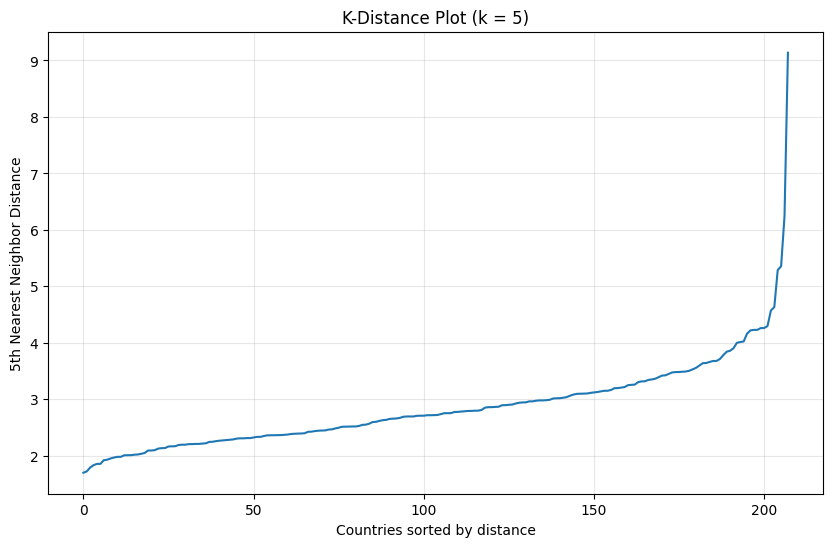

In [80]:
# Calculating 5-nearest-neighbor distances

neighbors_5 = NearestNeighbors(
    n_neighbors=5
)

neighbors_5.fit(X_scaled)

distances_5, indices_5 = neighbors_5.kneighbors(X_scaled)

# Distance to the 5th nearest neighbor
k_distance_5 = np.sort(distances_5[:, -1])

plt.figure(figsize=(10, 6))

plt.plot(k_distance_5)

plt.xlabel("Countries sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot (k = 5)")

plt.grid(True, alpha=0.3)

plt.show()

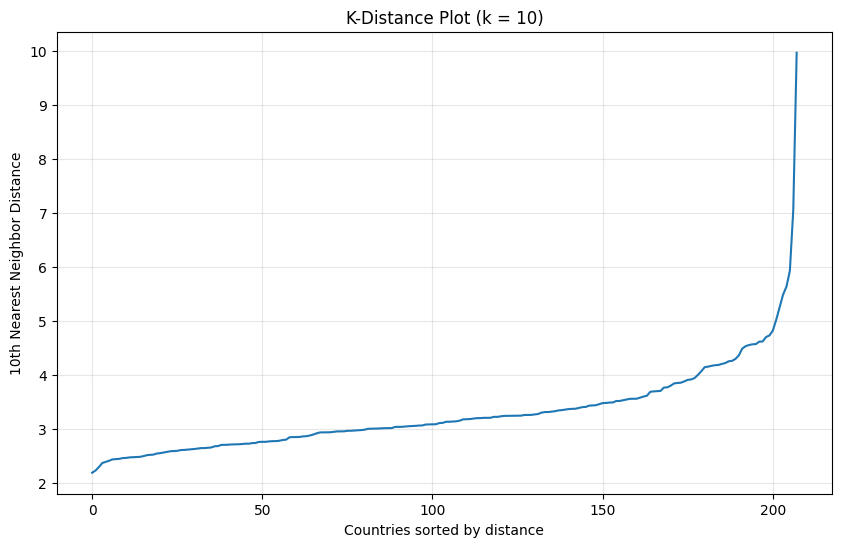

In [81]:
# Calculating 10-nearest-neighbor distances

neighbors_10 = NearestNeighbors(
    n_neighbors=10
)

neighbors_10.fit(X_scaled)

distances_10, indices_10 = neighbors_10.kneighbors(X_scaled)

k_distance_10 = np.sort(distances_10[:, -1])

plt.figure(figsize=(10, 6))

plt.plot(k_distance_10)

plt.xlabel("Countries sorted by distance")
plt.ylabel("10th Nearest Neighbor Distance")
plt.title("K-Distance Plot (k = 10)")

plt.grid(True, alpha=0.3)

plt.show()

### DBSCAN Parameter Experimentation

DBSCAN does not require the number of clusters to be specified in advance. Instead, clusters are determined by the density of observations.

Based on the k-distance plots, a range of eps values around the observed elbow region is evaluated. Different values of min_samples are also tested to assess the effect of the minimum density requirement.

The resulting models are compared using Silhouette Score, number of clusters, and proportion of observations classified as noise.

**DBSCAN Hyperparameter Tuning:**

In [82]:
# DBSCAN hyperparameter tuning

eps_values = [3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0]
min_samples_values = [5, 10]

dbscan_results = []

for min_samples in min_samples_values:
    
    for eps in eps_values:
        
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = dbscan.fit_predict(X_scaled)
        
        # Identifying non-noise observations
        non_noise_mask = labels != -1
        non_noise_labels = labels[non_noise_mask]
        non_noise_data = X_scaled[non_noise_mask]
        
        # Number of clusters excluding noise
        n_clusters = len(
            set(non_noise_labels)
        )
        
        # Number and percentage of noise observations
        n_noise = np.sum(labels == -1)
        noise_percentage = (
            n_noise / len(labels)
        ) * 100
        
        # Calculating silhouette only when at least two non-noise clusters exist
        if n_clusters >= 2:
            silhouette = silhouette_score(
                non_noise_data,
                non_noise_labels
            )
        else:
            silhouette = np.nan
        
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'Number of Clusters': n_clusters,
            'Noise Points': n_noise,
            'Noise Percentage': noise_percentage,
            'Silhouette Score': silhouette
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df

,eps,min_samples,Number of Clusters,Noise Points,Noise Percentage,Silhouette Score
0,3.50,5,1,11,5.288462,NaN
1,3.75,5,1,9,4.326923,NaN
2,4.00,5,1,7,3.365385,NaN
3,4.25,5,1,5,2.403846,NaN
4,4.50,5,1,2,0.961538,NaN
5,4.75,5,1,1,0.480769,NaN
6,5.00,5,1,1,0.480769,NaN
7,3.50,10,1,16,7.692308,NaN
8,3.75,10,1,11,5.288462,NaN
9,4.00,10,1,10,4.807692,NaN


**Observation:**

The initial eps range resulted in a single dominant cluster across all tested configurations. Therefore, a lower range of eps values needs to be evaluated to identify whether smaller neighborhood radii produce multiple meaningful density-based clusters.

**Refined DBSCAN Parameter Search:**

In [83]:
# Refined DBSCAN hyperparameter search

eps_values_refined = np.arange(1.0, 3.51, 0.25)
min_samples_values = [5, 10]

dbscan_refined_results = []

for min_samples in min_samples_values:
    
    for eps in eps_values_refined:
        
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = dbscan.fit_predict(X_scaled)
        
        # Exclude noise points
        non_noise_mask = labels != -1
        non_noise_labels = labels[non_noise_mask]
        non_noise_data = X_scaled[non_noise_mask]
        
        # Number of clusters excluding noise
        n_clusters = len(set(non_noise_labels))
        
        # Noise information
        n_noise = np.sum(labels == -1)
        noise_percentage = (n_noise / len(labels)) * 100
        
        # Silhouette score only if there are at least 2 clusters
        if n_clusters >= 2:
            silhouette = silhouette_score(
                non_noise_data,
                non_noise_labels
            )
        else:
            silhouette = np.nan
        
        dbscan_refined_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'Number of Clusters': n_clusters,
            'Noise Points': n_noise,
            'Noise Percentage': noise_percentage,
            'Silhouette Score': silhouette
        })

dbscan_refined_df = pd.DataFrame(
    dbscan_refined_results
)

dbscan_refined_df

,eps,min_samples,Number of Clusters,Noise Points,Noise Percentage,Silhouette Score
0,1.00,5,0,208,100.000000,NaN
1,1.25,5,0,208,100.000000,NaN
2,1.50,5,0,208,100.000000,NaN
3,1.75,5,2,198,95.192308,0.745144
4,2.00,5,5,172,82.692308,0.419617
5,2.25,5,5,124,59.615385,0.346707
6,2.50,5,4,93,44.711538,0.316110
7,2.75,5,3,56,26.923077,0.266013
8,3.00,5,1,36,17.307692,NaN
9,3.25,5,1,24,11.538462,NaN


In [84]:
# DBSCAN configurations producing at least 2 clusters

valid_dbscan_results = (
    dbscan_refined_df[
        dbscan_refined_df['Number of Clusters'] >= 2
    ]
    .sort_values(
        by='Silhouette Score',
        ascending=False
    )
)

valid_dbscan_results

,eps,min_samples,Number of Clusters,Noise Points,Noise Percentage,Silhouette Score
3,1.75,5,2,198,95.192308,0.745144
17,2.50,10,3,133,63.942308,0.424920
4,2.00,5,5,172,82.692308,0.419617
16,2.25,10,2,188,90.384615,0.416291
5,2.25,5,5,124,59.615385,0.346707
18,2.75,10,3,89,42.788462,0.334546
6,2.50,5,4,93,44.711538,0.316110
7,2.75,5,3,56,26.923077,0.266013


**Fine-Tuning eps:**

In [85]:
# Fine-tuning DBSCAN eps around the transition region

eps_values_fine = np.arange(2.75, 3.51, 0.10)

fine_results = []

for eps in eps_values_fine:
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = dbscan.fit_predict(X_scaled)
    
    non_noise_mask = labels != -1
    non_noise_labels = labels[non_noise_mask]
    non_noise_data = X_scaled[non_noise_mask]
    
    n_clusters = len(set(non_noise_labels))
    n_noise = np.sum(labels == -1)
    noise_percentage = (n_noise / len(labels)) * 100
    
    if n_clusters >= 2:
        silhouette = silhouette_score(
            non_noise_data,
            non_noise_labels
        )
    else:
        silhouette = np.nan
    
    fine_results.append({
        'eps': eps,
        'Number of Clusters': n_clusters,
        'Noise Points': n_noise,
        'Noise Percentage': noise_percentage,
        'Silhouette Score': silhouette
    })

dbscan_fine_df = pd.DataFrame(fine_results)

dbscan_fine_df

,eps,Number of Clusters,Noise Points,Noise Percentage,Silhouette Score
0,2.75,3,56,26.923077,0.266013
1,2.85,1,43,20.673077,NaN
2,2.95,1,37,17.788462,NaN
3,3.05,1,34,16.346154,NaN
4,3.15,1,31,14.903846,NaN
5,3.25,1,24,11.538462,NaN
6,3.35,1,19,9.134615,NaN
7,3.45,1,14,6.730769,NaN


In [86]:
# Only showing configurations with at least 2 clusters

dbscan_fine_valid = (
    dbscan_fine_df[
        dbscan_fine_df['Number of Clusters'] >= 2
    ]
    .sort_values(
        'Silhouette Score',
        ascending=False
    )
)

dbscan_fine_valid

,eps,Number of Clusters,Noise Points,Noise Percentage,Silhouette Score
0,2.75,3,56,26.923077,0.266013


### Inspecting the DBSCAN Candidate

**Final DBSCAN Candidate**

The refined parameter search identified only one configuration that produced multiple clusters without classifying the majority of observations as noise: eps = 2.75 and min_samples = 5.

This configuration produces three clusters and 56 noise observations. The resulting cluster sizes and profiles are examined before determining whether DBSCAN provides a useful segmentation for the dataset.

In [87]:
# Fitting the candidate DBSCAN model

dbscan_final_candidate = DBSCAN(
    eps=2.75,
    min_samples=5
)

dbscan_labels = dbscan_final_candidate.fit_predict(X_scaled)

# Store labels
country_df['DBSCAN_Cluster'] = dbscan_labels

print("Silhouette Score:",
      silhouette_score(
          X_scaled[dbscan_labels != -1],
          dbscan_labels[dbscan_labels != -1]
      ))

print("Number of clusters:",
      len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))

print("Noise points:",
      np.sum(dbscan_labels == -1))

print("Noise percentage:",
      np.mean(dbscan_labels == -1) * 100)

Silhouette Score: 0.26601261050671193
Number of clusters: 3
Noise points: 56
Noise percentage: 26.923076923076923


In [88]:
# DBSCAN cluster sizes

dbscan_cluster_sizes = (
    country_df['DBSCAN_Cluster']
    .value_counts()
    .sort_index()
)

dbscan_cluster_sizes

DBSCAN_Cluster
-1     56
 0     37
 1    101
 2     14
Name: count, dtype: int64

**DBSCAN Cluster Profiles:**

In [89]:
# Profile DBSCAN clusters excluding noise

dbscan_profile = (
    country_df[
        country_df['DBSCAN_Cluster'] != -1
    ]
    .groupby('DBSCAN_Cluster')[feature_cols]
    .mean()
)

dbscan_profile

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
DBSCAN_Cluster,,,,,,,,,,,,,,,,,,,,,,,
0,0.038349,49.760039,5910.513514,43.016581,144.972973,9237.004505,1.199451e+10,0.055278,39.237573,333.701255,0.070337,0.022370,0.161136,57.609148,55.166320,0.206255,0.432649,0.536058,0.031279,1.964152e+07,0.320653,3.091614e+08,2.388649e+08
1,0.015972,42.696312,118174.727633,27.866447,72.891089,50535.850279,2.814871e+11,0.068375,1117.688500,284.712624,0.015273,0.344441,0.118263,77.888643,71.926585,0.705863,0.247144,0.656146,0.096551,2.112160e+07,0.675065,5.927607e+09,5.591315e+09
2,0.022408,35.058036,370.506494,29.596230,85.214286,131.321429,7.618277e+08,0.051945,264.324176,156.267857,0.018753,0.188670,0.115788,73.289710,68.447053,0.554437,0.331385,0.613253,0.055126,2.396580e+05,0.340220,1.219053e+08,2.801073e+07


In [90]:
# Countries classified as DBSCAN noise

dbscan_noise_countries = (
    country_df[
        country_df['DBSCAN_Cluster'] == -1
    ][['Country']]
    .sort_values('Country')
)

dbscan_noise_countries

,Country
5,Angola
7,Argentina
13,"Bahamas, The"
14,Bahrain
17,Belarus
25,Botswana
26,Brazil
27,Brunei Darussalam
30,Burundi
38,China


### Final DBSCAN Visualization

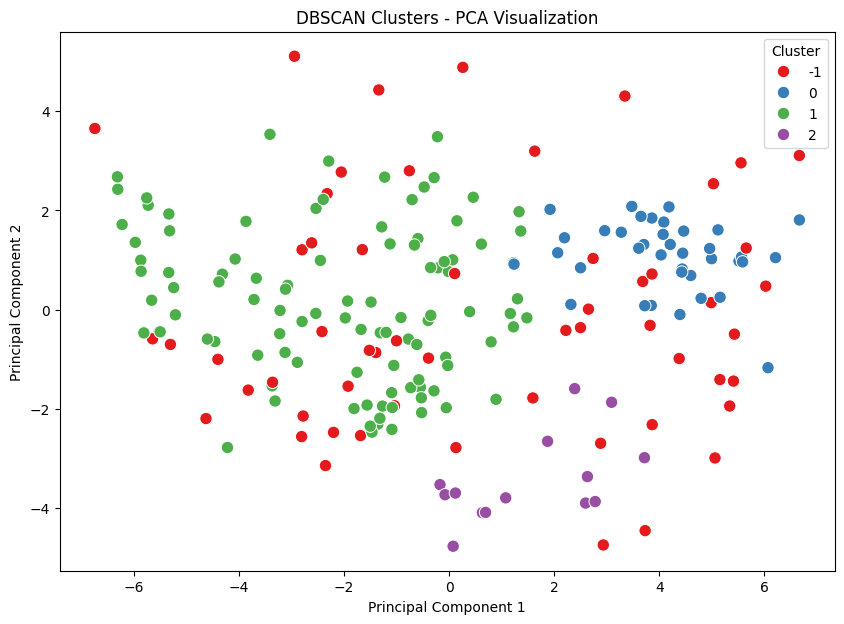

In [91]:
# PCA visualization of DBSCAN clusters

pca_dbscan_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_dbscan_df['DBSCAN_Cluster'] = dbscan_labels

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_dbscan_df,
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    palette='Set1',
    s=80
)

plt.title("DBSCAN Clusters - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

# Final Model Comparison

**Comparative Analysis of Clustering Models**

The **3 clustering approaches (K-Means, Hierarchial & DBSCAN)** are compared using Silhouette Score, number of clusters, cluster coverage, and noise observations. This comparison considers both statistical clustering quality and practical usefulness for country segmentation.

In [92]:
# Final clustering model comparison

comparison_df = pd.DataFrame({
    'Model': [
        'K-Means',
        'Hierarchical - Complete Linkage',
        'DBSCAN'
    ],
    'Number of Clusters': [
        2,
        2,
        3
    ],
    'Silhouette Score': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hc_labels),
        silhouette_score(
            X_scaled[dbscan_labels != -1],
            dbscan_labels[dbscan_labels != -1]
        )
    ],
    'Countries Assigned': [
        len(kmeans_labels),
        len(hc_labels),
        np.sum(dbscan_labels != -1)
    ],
    'Noise Countries': [
        0,
        0,
        np.sum(dbscan_labels == -1)
    ]
})

comparison_df

,Model,Number of Clusters,Silhouette Score,Countries Assigned,Noise Countries
0,K-Means,2,0.309315,208,0
1,Hierarchical - Complete Linkage,2,0.294261,208,0
2,DBSCAN,3,0.266013,152,56


In [93]:
# Adding coverage percentage

comparison_df['Coverage (%)'] = (
    comparison_df['Countries Assigned'] / len(country_df)
) * 100

comparison_df

,Model,Number of Clusters,Silhouette Score,Countries Assigned,Noise Countries,Coverage (%)
0,K-Means,2,0.309315,208,0,100.000000
1,Hierarchical - Complete Linkage,2,0.294261,208,0,100.000000
2,DBSCAN,3,0.266013,152,56,73.076923


# Final Model Selection

Three clustering approaches were evaluated: K-Means, Hierarchical Clustering, and DBSCAN.

**K-Means** with two clusters achieved the highest Silhouette Score among the models providing complete country coverage, with a score of 0.3093 and 100% of the 208 countries assigned to clusters.

**Hierarchical Clustering** using Complete Linkage with two clusters achieved a comparable Silhouette Score of 0.2943 and also provided 100% coverage.

**DBSCAN** identified three dense groups with a Silhouette Score of 0.2660, but classified 56 countries (26.92%) as noise, resulting in only 73.08% coverage.

Therefore, **K-Means with two clusters is selected as the final model for deployment**. The resulting clusters represent two broad country development profiles: a Lower Development Profile and a Higher Development Profile.

Now, we will examine Cluster profiles using the original-scale development indicators to understand the characteristics of each country segment.

# Final K-Means Cluster Profiles

In [94]:
# Final K-Means cluster profiles

final_kmeans_profile = (
    country_df
    .groupby('KMeans_Cluster')[feature_cols]
    .mean()
)

final_kmeans_profile

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,,,
0,0.034136,57.233237,9635.407923,56.894995,136.462500,9122.460417,1.414935e+10,0.059812,89.939685,300.538393,0.059671,0.045313,0.192896,60.992308,57.808654,0.264791,0.406186,0.557989,0.035790,1.645374e+07,0.368272,2.426291e+08,2.636142e+08
1,0.015190,41.565412,209771.957789,28.180667,68.726562,83472.463205,3.886288e+11,0.066111,1136.847356,288.128571,0.014025,0.355549,0.112869,77.902333,72.158395,0.761768,0.238047,0.667317,0.094464,4.083451e+07,0.684583,6.911051e+09,6.319060e+09


**Identifying the Most Distinguishing Features:**

In [95]:
# Comparing the two K-Means cluster profiles

cluster_0 = final_kmeans_profile.loc[0]
cluster_1 = final_kmeans_profile.loc[1]

profile_comparison = pd.DataFrame({
    'Cluster 0': cluster_0,
    'Cluster 1': cluster_1
})

profile_comparison['Absolute Difference'] = (
    profile_comparison['Cluster 1'] -
    profile_comparison['Cluster 0']
).abs()

profile_comparison.sort_values(
    'Absolute Difference',
    ascending=False
)

,Cluster 0,Cluster 1,Absolute Difference
GDP,1.414935e+10,3.886288e+11,3.744795e+11
Tourism Inbound,2.426291e+08,6.911051e+09,6.668422e+09
Tourism Outbound,2.636142e+08,6.319060e+09,6.055445e+09
Population Total,1.645374e+07,4.083451e+07,2.438077e+07
CO2 Emissions,9.635408e+03,2.097720e+05,2.001365e+05
Energy Usage,9.122460e+03,8.347246e+04,7.435000e+04
Health Exp/Capita,8.993969e+01,1.136847e+03,1.046908e+03
Ease of Business,1.364625e+02,6.872656e+01,6.773594e+01
Days to Start Business,5.689500e+01,2.818067e+01,2.871433e+01
Life Expectancy Female,6.099231e+01,7.790233e+01,1.691003e+01


**Final Cluster Sizes:**

In [96]:
# Final K-Means cluster sizes and percentages

final_cluster_sizes = (
    country_df['KMeans_Cluster']
    .value_counts()
    .sort_index()
)

final_cluster_summary = pd.DataFrame({
    'Number of Countries': final_cluster_sizes,
    'Percentage of Countries':
        (final_cluster_sizes / len(country_df)) * 100
})

final_cluster_summary

,Number of Countries,Percentage of Countries
KMeans_Cluster,,
0,80,38.461538
1,128,61.538462


**Country Lists:**

In [97]:
# Countries belonging to each final K-Means cluster

for cluster in sorted(country_df['KMeans_Cluster'].unique()):
    
    print(f"\nK-Means Cluster {cluster}")
    print("-" * 60)
    
    countries = (
        country_df[
            country_df['KMeans_Cluster'] == cluster
        ]['Country']
        .sort_values()
        .tolist()
    )
    
    print(", ".join(countries))


K-Means Cluster 0
------------------------------------------------------------
Afghanistan, Angola, Bangladesh, Belize, Benin, Bhutan, Bolivia, Botswana, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Djibouti, Equatorial Guinea, Eritrea, Ethiopia, Fiji, Gabon, Gambia, The, Ghana, Grenada, Guatemala, Guinea, Guinea-Bissau, Guyana, Haiti, Honduras, Iraq, Kenya, Kiribati, Kyrgyz Republic, Lao PDR, Lesotho, Liberia, Madagascar, Malawi, Mali, Marshall Islands, Mauritania, Micronesia, Fed. Sts., Mongolia, Mozambique, Myanmar, Namibia, Nepal, Nicaragua, Niger, Nigeria, Pakistan, Papua New Guinea, Paraguay, Rwanda, Samoa, Sao Tome and Principe, Senegal, Sierra Leone, Solomon Islands, Somalia, South Sudan, Sudan, Suriname, Swaziland, Tajikistan, Tanzania, Timor-Leste, Togo, Tonga, Turkmenistan, Uganda, Uzbekistan, Vanuatu, Yemen, Rep., Zambia, Zimbabwe

K-Means Cluster 1
----------------------------------------

## Giving meaningful names to numeric cluster labels

In [98]:
# Mapping K-Means cluster numbers to meaningful descriptions

cluster_names = {
    0: 'Lower Development Profile',
    1: 'Higher Development Profile'
}

country_df['KMeans_Profile'] = (
    country_df['KMeans_Cluster']
    .map(cluster_names)
)

country_df[
    ['Country', 'KMeans_Cluster', 'KMeans_Profile']
].head()

,Country,KMeans_Cluster,KMeans_Profile
0,Afghanistan,0,Lower Development Profile
1,Albania,1,Higher Development Profile
2,Algeria,1,Higher Development Profile
3,American Samoa,1,Higher Development Profile
4,Andorra,1,Higher Development Profile


# Deployment Preparation

## Preparing Model Artifacts for Deployment

We will save the final K-Means model and preprocessing components as reusable artifacts for the Streamlit application.

The deployment artifacts include:

- Trained K-Means model
- StandardScaler used during training
- List of model features
- Country-level processed dataset
- Cluster descriptions

Saving these components ensures that the Streamlit application uses the same preprocessing and clustering configuration as the final notebook.

**Saving the final K-Means model:**

In [99]:
# Saving the final K-Means model
joblib.dump(
    kmeans_final,
    'kmeans_model.pkl'
)

['kmeans_model.pkl']

**Saving the fitted scaler:**

In [100]:
# Saving the fitted StandardScaler
joblib.dump(
    scaler,
    'scaler.pkl'
)

['scaler.pkl']

**Saving the feature list:**

In [101]:
# Saving the exact feature order used during training
joblib.dump(
    feature_cols,
    'feature_columns.pkl'
)

['feature_columns.pkl']

**Saving the median values:**

In [102]:
# Saving the median values used during training

imputation_medians = country_df[feature_cols].median()

joblib.dump(
    imputation_medians,
    'imputation_medians.pkl'
)

['imputation_medians.pkl']

In [103]:
print("Median values saved for all features:")
print(imputation_medians)

Median values saved for all features:
Birth Rate                1.957692e-02
Business Tax Rate         4.106250e+01
CO2 Emissions             7.856455e+03
Days to Start Business    2.770000e+01
Ease of Business          9.400000e+01
Energy Usage              8.974167e+03
GDP                       1.706592e+10
Health Exp % GDP          6.076923e-02
Health Exp/Capita         2.193846e+02
Hours to do Tax           2.410000e+02
Infant Mortality Rate     2.000000e-02
Internet Usage            1.692308e-01
Lending Interest          1.211538e-01
Life Expectancy Female    7.530769e+01
Life Expectancy Male      6.900000e+01
Mobile Phone Usage        5.615385e-01
Population 0-14           3.003077e-01
Population 15-64          6.446538e-01
Population 65+            5.346154e-02
Population Total          5.698424e+06
Population Urban          5.600769e-01
Tourism Inbound           6.570385e+08
Tourism Outbound          4.347094e+08
dtype: float64


## Saving the Country-Level Dataset

In [104]:
# Saving country-level development profiles and cluster assignments

deployment_df = country_df[
    ['Country'] +
    feature_cols +
    ['KMeans_Cluster', 'KMeans_Profile']
].copy()

deployment_df.to_csv(
    'country_development_profiles.csv',
    index=False
)

deployment_df.head()

,Country,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,KMeans_Cluster,KMeans_Profile
0,Afghanistan,0.043154,36.3000,2375.727273,8.111111,170.0,8974.166667,9.718945e+09,0.091909,30.636364,275.0,0.082769,0.016667,0.159714,58.769231,56.384615,0.254545,0.490308,0.488769,0.020769,2.539926e+07,0.232923,1.060000e+08,8.240000e+07,0,Lower Development Profile
1,Albania,0.014692,42.5500,3902.090909,23.000000,82.0,2024.583333,8.895522e+09,0.061462,168.846154,364.5,0.017769,0.192308,0.142385,79.230769,73.000000,0.561538,0.258385,0.653692,0.087923,2.956845e+06,0.478538,1.165231e+09,1.007077e+09,1,Higher Development Profile
2,Algeria,0.022077,73.7125,102837.636364,25.000000,151.0,34042.166667,1.190391e+11,0.038462,133.846154,451.0,0.027769,0.069231,0.083231,71.615385,68.384615,0.492308,0.292692,0.663077,0.044231,3.476067e+07,0.645154,2.752308e+08,4.513077e+08,1,Higher Development Profile
3,American Samoa,0.020500,41.0625,7856.454545,27.700000,94.0,8974.166667,1.706592e+10,0.060769,219.384615,241.0,0.020000,0.169231,0.121154,75.307692,69.000000,0.000000,0.300308,0.644654,0.053462,5.752538e+04,0.880000,6.570385e+08,4.347094e+08,1,Higher Development Profile
4,Andorra,0.010583,41.0625,537.636364,27.700000,94.0,8974.166667,2.268380e+09,0.063231,2394.461538,241.0,0.003000,0.516667,0.121154,75.307692,69.000000,0.700000,0.300308,0.644654,0.053462,7.668408e+04,0.897462,6.570385e+08,4.347094e+08,1,Higher Development Profile


## Creating a Model Metadata File

In [105]:
# Saving model metadata

model_metadata = {
    'model': 'K-Means',
    'n_clusters': 2,
    'silhouette_score': 0.309315,
    'features': feature_cols,
    'cluster_names': cluster_names,
    'log_transformed_features': log_features
}

joblib.dump(
    model_metadata,
    'model_metadata.pkl'
)

['model_metadata.pkl']

## Verifying the Saved Artifacts

In [106]:
# Verifying deployment artifacts

loaded_model = joblib.load('kmeans_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_features = joblib.load('feature_columns.pkl')
loaded_metadata = joblib.load('model_metadata.pkl')

print("Model:", type(loaded_model).__name__)
print("Scaler:", type(loaded_scaler).__name__)
print("Number of features:", len(loaded_features))
print("Clusters:", loaded_model.n_clusters)
print("Model metadata:", loaded_metadata)

Model: KMeans
Scaler: StandardScaler
Number of features: 23
Clusters: 2
Model metadata: {'model': 'K-Means', 'n_clusters': 2, 'silhouette_score': 0.309315, 'features': ['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP', 'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate', 'Internet Usage', 'Lending Interest', 'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage', 'Population 0-14', 'Population 15-64', 'Population 65+', 'Population Total', 'Population Urban', 'Tourism Inbound', 'Tourism Outbound'], 'cluster_names': {0: 'Lower Development Profile', 1: 'Higher Development Profile'}, 'log_transformed_features': ['GDP', 'Lending Interest', 'Population Total', 'Days to Start Business', 'CO2 Emissions', 'Energy Usage', 'Tourism Inbound', 'Tourism Outbound', 'Hours to do Tax', 'Business Tax Rate', 'Health Exp/Capita']}


In [107]:
# Verifying saved imputation medians

loaded_medians = joblib.load(
    'imputation_medians.pkl'
)

print("Number of saved medians:", len(loaded_medians))
print("Missing median values:", loaded_medians.isnull().sum())

Number of saved medians: 23
Missing median values: 0


In [108]:
# Verifying country dataset

loaded_country_data = pd.read_csv(
    'country_development_profiles.csv'
)

print("Country dataset shape:", loaded_country_data.shape)
print(
    "Countries:",
    loaded_country_data['Country'].nunique()
)
print(
    "Missing values:",
    loaded_country_data.isnull().sum().sum()
)

Country dataset shape: (208, 26)
Countries: 208
Missing values: 0


# New Country Prediction Pipeline & Validation

**Function to preprocess new-country data using the same transformations applied during model training:**

In [ ]:
def preprocess_new_country(
    input_df,
    feature_cols,
    log_features,
    imputation_medians,
    scaler
):
    """
    Preprocess a new country's development indicators
    using the same transformations applied during model training.
    """
    
    # Ensuring the features are in the exact training order
    input_df = input_df[feature_cols].copy()
    
    # Handling missing values using training-set medians
    input_df = input_df.fillna(imputation_medians)
    
    # Applying log1p transformation to the same skewed features
    input_df[log_features] = np.log1p(
        input_df[log_features]
    )
    
    # Applying the fitted StandardScaler
    X_new_scaled = scaler.transform(input_df)
    
    return X_new_scaled

**Selecting an existing country for validation:**

In [ ]:
test_country = "India"

test_row = country_df[
    country_df["Country"] == test_country
][feature_cols].copy()

print("Input shape:", test_row.shape)
print("Missing values:", test_row.isnull().sum().sum())

Input shape: (1, 23)
Missing values: 0


**Preprocessing the test country:**

In [ ]:
X_test_scaled = preprocess_new_country(
    test_row,
    feature_cols,
    log_features,
    imputation_medians,
    scaler
)

print("Processed shape:", X_test_scaled.shape)

Processed shape: (1, 23)


**Predicting the cluster using the saved final K-Means model:**

In [ ]:
predicted_cluster = kmeans_final.predict(
    X_test_scaled
)[0]

actual_cluster = int(
    country_df[
        country_df["Country"] == test_country
    ]["KMeans_Cluster"].iloc[0]
)

print("Country:", test_country)
print("Predicted cluster:", predicted_cluster)
print("Existing cluster:", actual_cluster)
print("Prediction matches:", predicted_cluster == actual_cluster)

Country: India
Predicted cluster: 1
Existing cluster: 1
Prediction matches: True
